### LSE Data Analytics Online Career Accelerator 

# DA301:  Advanced Analytics for Organisational Impact

## Assignment template

### Scenario
You are a data analyst working for Turtle Games, a game manufacturer and retailer. They manufacture and sell their own products, along with sourcing and selling products manufactured by other companies. Their product range includes books, board games, video games and toys. They have a global customer base and have a business objective of improving overall sales performance by utilising customer trends. In particular, Turtle Games wants to understand: 
- how customers accumulate loyalty points (Week 1)
- exploring the structure using decision trees (Week 2)
- exploring clusters in customer behaviour (Week 3)
- can social data (e.g. customer reviews) be used in marketing campaigns (Week 4)
- loading, transforming and visualising data in R (Week 5)
- statistical analysis and modelling in R (Week 6)

# Week 1 assignment: Linear regression using Python
The marketing department of Turtle Games prefers Python for data analysis. As you are fluent in Python, they asked you to assist with data analysis of social media data. The marketing department wants to better understand how users accumulate loyalty points. Therefore, you need to investigate the possible relationships between the loyalty points, age, remuneration, and spending scores. Note that you will use this data set in future modules as well and it is, therefore, strongly encouraged to first clean the data as per provided guidelines and then save a copy of the clean data for future use.

## Instructions
1. Load and explore the data.
    1. Create a new DataFrame (e.g. reviews).
    2. Sense-check the DataFrame.
    3. Determine if there are any missing values in the DataFrame.
    4. Create a summary of the descriptive statistics.
2. Remove redundant columns (`language` and `platform`).
3. Change column headings to names that are easier to reference (e.g. `renumeration` and `spending_score`).
4. Save a copy of the clean DataFrame as a CSV file. Import the file to sense-check.
5. Use linear regression and goodness of fit metrics to evaluate possible linear relationships between loyalty points and age/renumeration/spending scores to determine whether these can be used to predict the loyalty points.
    1. Specify the independent and dependent variables.
    2. Create the OLS model.
    3. Extract the estimated parameters, standard errors, and predicted values.
    4. Generate the regression table based on the X coefficient and constant values.
    5. Plot the linear regression and add a regression line.
6. Include your insights and observations.

## 1. Load and explore the data

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import re
import statsmodels.api as sm 
import statsmodels.stats.api as sms
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from collections import Counter
from nltk.probability import FreqDist
from nltk.corpus import stopwords
import sklearn
from sklearn import metrics
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
# Load the CSV file(s) as reviews.
reviews = pd.read_csv('turtle_reviews.csv')

# View the DataFrame.
reviews

,gender,age,remuneration (k£),spending_score (1-100),loyalty_points,education,language,platform,product,review,summary
0,Male,18,12.30,39,210,graduate,EN,Web,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,EN,Web,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,EN,Web,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,EN,Web,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,EN,Web,291,As my review of GF9's previous screens these w...,Money trap
...,...,...,...,...,...,...,...,...,...,...,...
1995,Female,37,84.46,69,4031,PhD,EN,Web,977,The perfect word game for mixed ages (with Mom...,The perfect word game for mixed ages (with Mom
1996,Female,43,92.66,8,539,PhD,EN,Web,979,Great game. Did not think I would like it whe...,Super fun
1997,Male,34,92.66,91,5614,graduate,EN,Web,1012,Great game for all.........\nKeeps the mind ni...,Great Game
1998,Male,34,98.40,16,1048,PhD,EN,Web,1031,fun game!,Four Stars


In [3]:
# Any missing values?
reviews.isna().any().any()

False

In [4]:
# Explore the data.
reviews.duplicated(keep=False)

0       False
1       False
2       False
3       False
4       False
        ...  
1995    False
1996    False
1997    False
1998    False
1999    False
Length: 2000, dtype: bool

In [5]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   gender                  2000 non-null   object 
 1   age                     2000 non-null   int64  
 2   remuneration (k£)       2000 non-null   float64
 3   spending_score (1-100)  2000 non-null   int64  
 4   loyalty_points          2000 non-null   int64  
 5   education               2000 non-null   object 
 6   language                2000 non-null   object 
 7   platform                2000 non-null   object 
 8   product                 2000 non-null   int64  
 9   review                  2000 non-null   object 
 10  summary                 2000 non-null   object 
dtypes: float64(1), int64(4), object(6)
memory usage: 172.0+ KB


In [6]:
# Basic descriptive statistics.
reviews.describe()

,age,remuneration (k£),spending_score (1-100),loyalty_points,product
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,39.495000,48.079060,50.000000,1578.032000,4320.521500
std,13.573212,23.123984,26.094702,1283.239705,3148.938839
min,17.000000,12.300000,1.000000,25.000000,107.000000
25%,29.000000,30.340000,32.000000,772.000000,1589.250000
50%,38.000000,47.150000,50.000000,1276.000000,3624.000000
75%,49.000000,63.960000,73.000000,1751.250000,6654.000000
max,72.000000,112.340000,99.000000,6847.000000,11086.000000


## 2. Drop columns

In [7]:
# Drop unnecessary columns.
reviews.drop(columns=['language', 'platform'], axis = 1, inplace = True)

# View column names.
reviews.columns

Index(['gender', 'age', 'remuneration (k£)', 'spending_score (1-100)',
       'loyalty_points', 'education', 'product', 'review', 'summary'],
      dtype='object')

## 3. Rename columns

In [8]:
# Rename the column headers.
reviews.rename(columns={'remuneration (k£)':'pay',
                       'spending_score (1-100)':'spend',
                       'loyalty_points':'loyalty'}, inplace=True)

# View column names.
reviews.columns

Index(['gender', 'age', 'pay', 'spend', 'loyalty', 'education', 'product',
       'review', 'summary'],
      dtype='object')

## 4. Save the DataFrame as a CSV file

In [9]:
# Create a CSV file as output.
reviews.to_csv("turtle_reviews_clean.csv")

In [10]:
# Import new CSV file with Pandas.
reviews = pd.read_csv('turtle_reviews_clean.csv', index_col=0)

# View DataFrame.
reviews

,gender,age,pay,spend,loyalty,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap
...,...,...,...,...,...,...,...,...,...
1995,Female,37,84.46,69,4031,PhD,977,The perfect word game for mixed ages (with Mom...,The perfect word game for mixed ages (with Mom
1996,Female,43,92.66,8,539,PhD,979,Great game. Did not think I would like it whe...,Super fun
1997,Male,34,92.66,91,5614,graduate,1012,Great game for all.........\nKeeps the mind ni...,Great Game
1998,Male,34,98.40,16,1048,PhD,1031,fun game!,Four Stars


In [11]:
# Sense-check the DataFrame
reviews.shape

(2000, 9)

In [12]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   gender     2000 non-null   object 
 1   age        2000 non-null   int64  
 2   pay        2000 non-null   float64
 3   spend      2000 non-null   int64  
 4   loyalty    2000 non-null   int64  
 5   education  2000 non-null   object 
 6   product    2000 non-null   int64  
 7   review     2000 non-null   object 
 8   summary    2000 non-null   object 
dtypes: float64(1), int64(4), object(4)
memory usage: 156.2+ KB


## 5. Linear regression

### 5a) spend vs loyalty

In [13]:
# Define independent variable.
X = reviews['spend']

# Define dependent variable.
y = reviews['loyalty']

# Create model and print summary of metrics.
model1 = ols('loyalty~spend', data=reviews).fit()
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                loyalty   R-squared:                       0.452
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                     1648.
Date:                Sun, 05 Oct 2025   Prob (F-statistic):          2.92e-263
Time:                        19:42:15   Log-Likelihood:                -16550.
No. Observations:                2000   AIC:                         3.310e+04
Df Residuals:                    1998   BIC:                         3.312e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -75.0527     45.931     -1.634      0.102    -165.129      15.024
spend         33.0617      0.814     40.595      0.000      31.464      34.659
==============================================================================
Omnibus:                      126.554   Durbin-Watson:                   1.191
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              260.528
Skew:                           0.422   Prob(JB):                     2.67e-57
Kurtosis:                       4.554   Cond. No.                         122.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

- This model suggests that spend(x) explains 45% of the variance in loyalty points(y). The estimate of the intercept is not significant(p=0.102) - this is because of the heteroscedasticity in the data (tested below). The slope estimate is significant (p=0.000).

## Fitted vs Residual Plots model1

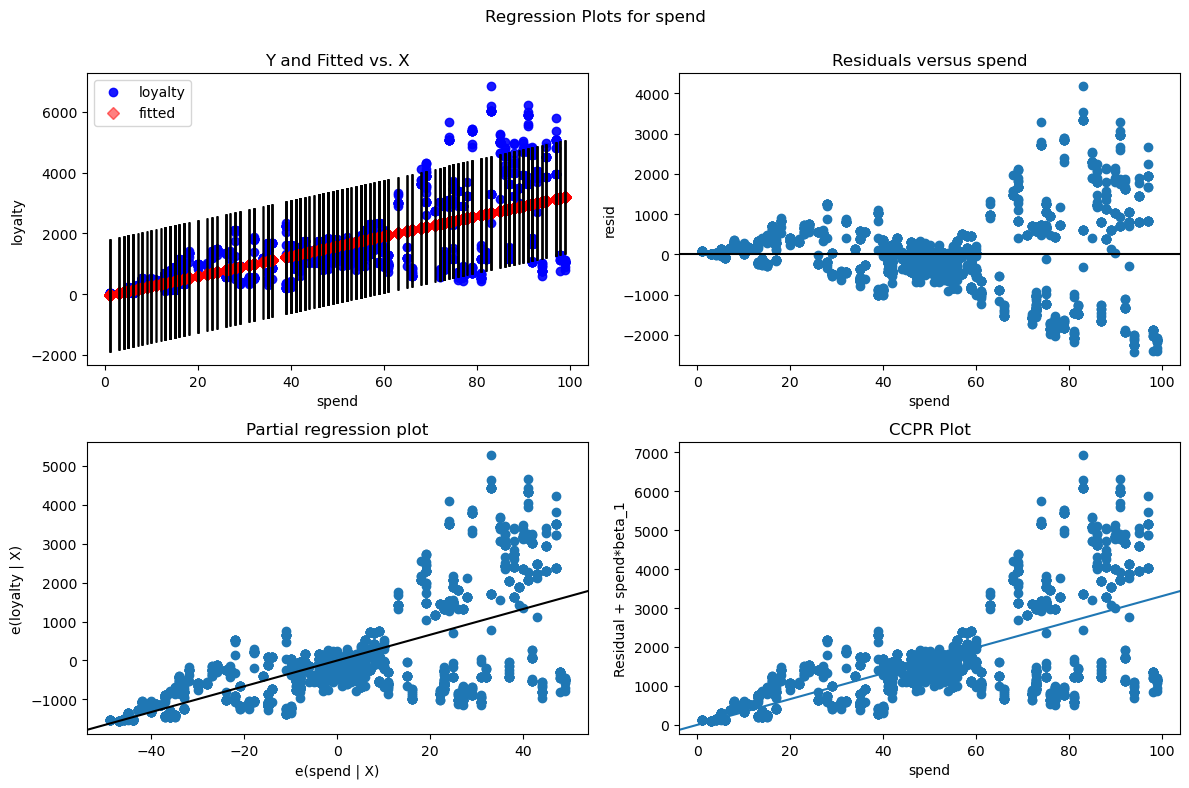

In [14]:
# Produce residual plots to assess distribution of residuals.
# Define figure size.
fig = plt.figure(figsize=(12,8))

# Produce regression plots.
fig = sm.graphics.plot_regress_exog(model1, 'spend', fig=fig)

## Run the Breusch-Pagan Test for Heteroscedasticity for model1

In [15]:
# Run the Breusch-Pagan test function on the model residuals and x-variables.
test = sms.het_breuschpagan(model1.resid, model1.model.exog)

# Print the results of the Breusch-Pagan test.
terms = ['LM stat', 'LM Test p-value', 'F-stat', 'F-test p-value']
print(dict(zip(terms, test)))

{'LM stat': 629.9823360215923, 'LM Test p-value': 5.042699614939363e-139, 'F-stat': 918.7507142907754, 'F-test p-value': 2.3037887924479145e-166}


- The LM Test p-value and F-test p-value for the Breusch-Pagan Test are both less than 0.05 (much less). We therefore reject the null hypothesis (which assumes homoscedasticity) and conclude that the data are heteroscedastic.

In [16]:
# Extract the estimated parameters.
print("Parameters: ", model1.params)

# Extract the standard errors.
print("Standard errors: ", model1.bse) 

# Extract the predicted values.
print("Predicted values: ", model1.predict())  

Parameters:  Intercept   -75.052663
spend        33.061693
dtype: float64
Standard errors:  Intercept    45.930554
spend         0.814419
dtype: float64
Predicted values:  [1214.35337415 2602.94449102  123.31749662 ... 2933.56142361  453.93442921
  189.44088314]


In [17]:
# Set the X coefficient and the constant to generate the regression table.
y_pred = (-75.0527) + (33.0617) * reviews['spend']

# View the output.
y_pred

0       1214.3536
1       2602.9450
2        123.3175
3       2470.6982
4       1247.4153
          ...    
1995    2206.2046
1996     189.4409
1997    2933.5620
1998     453.9345
1999     189.4409
Name: spend, Length: 2000, dtype: float64

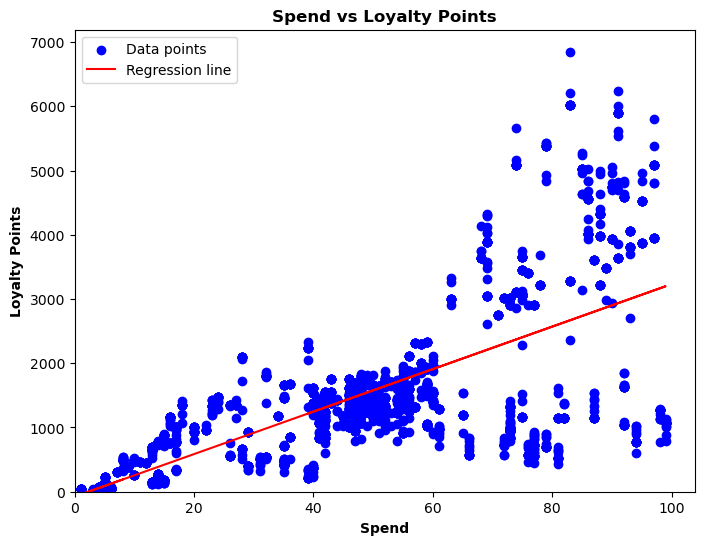

In [18]:
# Create a new figure and set the size
plt.figure(figsize=(8, 6))

# Plot the data points with a scatterplot
plt.scatter(X, y, color='blue', label='Data points')

# Plot the regression line
plt.plot(X, y_pred, color='red', label='Regression line')

# Set the x and y limits on the axes
plt.xlim(left=0)
plt.ylim(bottom=0)

# Set axis labels and title with bold fontweight
plt.xlabel('Spend', fontweight='bold')
plt.ylabel('Loyalty Points', fontweight='bold')
plt.title('Spend vs Loyalty Points', fontweight='bold')

# Add a legend for clarity
plt.legend()

# Save and show the plot
plt.savefig('LoyaltyvsSpendScatter.png')
plt.show()


The above plot shows the regression line with the data. It is clear that the spread around the line increases as the values of Spend(X) and Loyalty Points(y) increase.

### 5b) Pay vs loyalty

In [19]:
# Define independent variable.
X = reviews['pay']

# Define dependent variable.
y = reviews['loyalty']

# Create model and print summary of metrics.
model2 = ols('loyalty~pay', data=reviews).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                loyalty   R-squared:                       0.380
Model:                            OLS   Adj. R-squared:                  0.379
Method:                 Least Squares   F-statistic:                     1222.
Date:                Sun, 05 Oct 2025   Prob (F-statistic):          2.43e-209
Time:                        19:42:19   Log-Likelihood:                -16674.
No. Observations:                2000   AIC:                         3.335e+04
Df Residuals:                    1998   BIC:                         3.336e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -65.6865     52.171     -1.259      0.208    -168.001      36.628
pay           34.1878      0.978     34.960      0.000      32.270      36.106
==============================================================================
Omnibus:                       21.285   Durbin-Watson:                   3.622
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               31.715
Skew:                           0.089   Prob(JB):                     1.30e-07
Kurtosis:                       3.590   Cond. No.                         123.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

- This model explais that pay(X) explains 38% of the variance in loyalty points(y). The estimate of the intercept is not significant(p=0.208) - this is because of heteroscedasticity in the data (tested below). The slope estimate is significant (p=0.000).

## Fitted vs Residual Plots model2

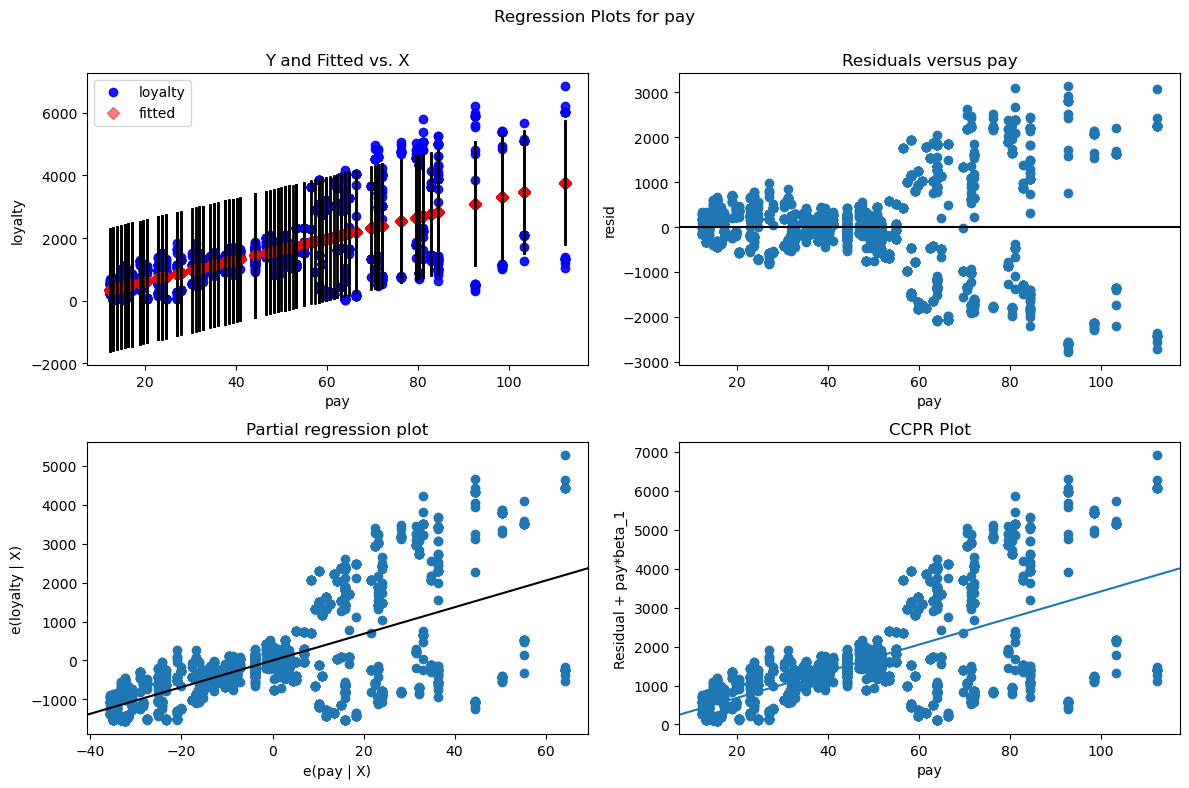

In [20]:
# Produce residual plots to assess distribution of residuals.
# Define figure size.
fig = plt.figure(figsize=(12,8))

# Produce regression plots.
fig = sm.graphics.plot_regress_exog(model2, 'pay', fig=fig)

## Run the Breusch-Pagan Test for Heteroscedasticity for model2

In [21]:
# Run the Breusch-Pagan test function on the model residuals and x-variables.
test = sms.het_breuschpagan(model2.resid, model2.model.exog)

# Print the results of the Breusch-Pagan test.
terms = ['LM stat', 'LM Test p-value', 'F-stat', 'F-test p-value']
print(dict(zip(terms, test)))

{'LM stat': 1038.6445487288277, 'LM Test p-value': 7.153051772824646e-228, 'F-stat': 2158.6311344219303, 'F-test p-value': 3.68e-320}


- The LM Test p-value and F-test p-value for the Breusch-Pagan Test are both less than 0.05 (much less). We therefore reject the null hypothesis (which assumes homoscedasticity) and conclude that the data are heteroscedastic.

In [22]:
# Extract the estimated parameters.
print("Parameters: ", model2.params)

# Extract the standard errors.
print("Standard Errors: ", model2.bse)

# Extract the predicted values.
y_pred = (-65.6865) + 34.1878 * reviews['pay']

y_pred

Parameters:  Intercept   -65.686513
pay          34.187825
dtype: float64
Standard Errors:  Intercept    52.170717
pay           0.977925
dtype: float64


0        354.823440
1        354.823440
2        382.857436
3        382.857436
4        410.891432
           ...     
1995    2821.815088
1996    3102.155048
1997    3102.155048
1998    3298.393020
1999    3102.155048
Name: pay, Length: 2000, dtype: float64

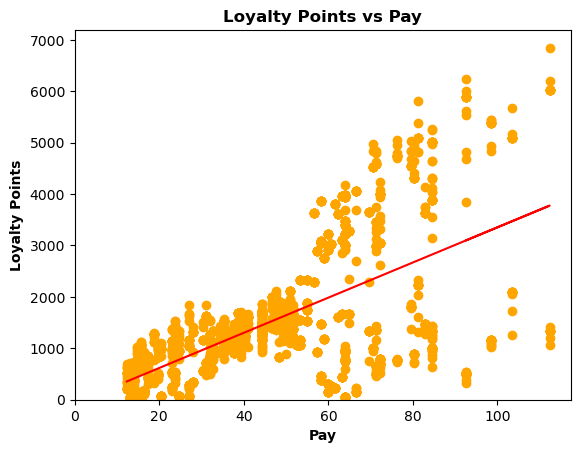

In [23]:
# Plot the data points with a scatterplot.
plt.scatter(X, y, color='orange')

X = reviews['pay']

# Plot the regression line.
plt.plot(X, y_pred, color='red')
plt.xlabel('Pay')
plt.ylabel('Loyalty Points')

# Set the x and y limits on the axes.
plt.xlim(0)
plt.ylim(0)
plt.xlabel('Pay', fontweight='bold')
plt.ylabel('Loyalty Points', fontweight='bold')
plt.title('Loyalty Points vs Pay', fontweight='bold')

# View the plot.
plt.savefig('loyalty_pay_scatter.png')
plt.show()

The above plot shows the regression line with the data. It can be seen that the spread around the regression line increases as Loyalty Points(y) increase with an increase in Pay(X).  

### 5c) age vs loyalty

In [24]:
# Define independent variable.
X = reviews['age']

# Define dependent variable.
y = reviews['loyalty']

# Create model and print summary of metrics.
model3 = ols('loyalty~age', data=reviews).fit()
model3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                loyalty   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     3.606
Date:                Sun, 05 Oct 2025   Prob (F-statistic):             0.0577
Time:                        19:42:23   Log-Likelihood:                -17150.
No. Observations:                2000   AIC:                         3.430e+04
Df Residuals:                    1998   BIC:                         3.431e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1736.5177     88.249     19.678      0.000    1563.449    1909.587
age           -4.0128      2.113     -1.899      0.058      -8.157       0.131
==============================================================================
Omnibus:                      481.477   Durbin-Watson:                   2.277
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              937.734
Skew:                           1.449   Prob(JB):                    2.36e-204
Kurtosis:                       4.688   Cond. No.                         129.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

- The OLS model suggests that age only explains 0.2% of the variance in loyalty points. The intercept estimate is significant (p<0.05) but the slope estimate is not (p=0.058).

In [25]:
# Extract the estimated parameters.
print("Parameters: ", model3.params)

# Extract the standard errors.
print("Standard Errors: ", model3.bse)

# Extract the predicted values.
y_pred = (1736.5177) + -4.0128 * reviews['age']

y_pred

Parameters:  Intercept    1736.517739
age            -4.012805
dtype: float64
Standard Errors:  Intercept    88.248731
age           2.113177
dtype: float64


0       1664.2873
1       1644.2233
2       1648.2361
3       1636.1977
4       1604.0953
          ...    
1995    1588.0441
1996    1563.9673
1997    1600.0825
1998    1600.0825
1999    1608.1081
Name: age, Length: 2000, dtype: float64

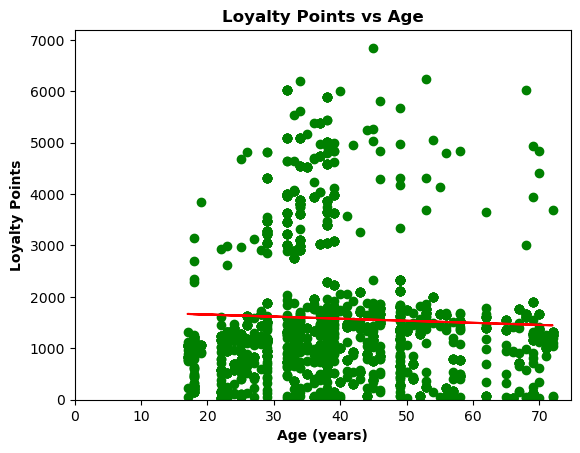

In [26]:
# Plot the graph with a regression line.
plt.scatter(data = reviews, x = 'age', y = 'loyalty', color='green')

X = reviews['age']            

# Plot the regression line (in red).
plt.plot(X, y_pred, color='red')

# Set the x and y limits on the axes.
plt.xlim(0)
plt.ylim(0)
plt.xlabel('Age (years)', fontweight='bold')
plt.ylabel('Loyalty Points', fontweight='bold')
plt.title('Loyalty Points vs Age', fontweight='bold')

# View the plot.
plt.show()

The above plot shows that there is no strong linear relationship between age and loyalty hence, no residuals are examined in this model.

## 6. Observations and insights

***Observations:***
- There is a significant linear relationship between spending score and loyalty, although it should be noted that loyalty points are awarded based in part on the amount a customer spends, so there is a structural connection between these two variables.
- There is a significant linear relationship between pay and loyalty.
- In both of the above cases, there is significant heteroscedasticity in the relationships (uneven variance) and is detected using the Breusch-Pagan test.
- There is no significant linear relationship between age and loyalty, and the OLS model fitted only explains 0.2% of the variance.
- The next step is to conduct a multiple linear regression using spend and pay as predictors of loyalty points.






## 7. Multiple Linear Regression: spend and pay as predictors of loyalty points: model4
- Multiple linear regression is performed using pay and spend to predict loyalty.

In [27]:
# Define the dependent variable.
y = reviews['loyalty']

# Define the independent variable.
X = reviews[['spend', 'pay']]

# Call and fit the multiple linear regression model.
mlr = linear_model.LinearRegression()
mlr.fit(X, y)

LinearRegression()

In [28]:
# Call the predictions for X (array)
mlr.predict(X)

array([ 4.57831319e-01,  1.38195101e+03, -1.05713790e+03, ...,
        4.44147048e+03,  2.16956070e+03,  1.71137682e+03])

In [29]:
# Print the R-squared value (coefficient of determination). 
# This is the proportion of variance in y explained by X.
print("R-squared: ", mlr.score(X,y))  

# Print the intercept.
print("Intercept: ", mlr.intercept_) 

# Print the coefficients.
print("Coefficients:")  

# Map a similar index of multiple containers (to be used as a single entity).
list(zip(X, mlr.coef_))  

R-squared:  0.8269134701989259
Intercept:  -1700.3050970144384
Coefficients:


[('spend', 32.892694687821), ('pay', 33.97949882180285)]

In [30]:
# Create a dataframe of predicted and observed loyalty values for model4.
# This will be used to create a plot for the report.
m4plot = pd.DataFrame(columns=['Observed Loyalty', 'Predicted Loyalty'])
m4plot['Observed Loyalty'] = reviews['loyalty']
m4plot['Predicted Loyalty'] = mlr.predict(X)
m4plot

,Observed Loyalty,Predicted Loyalty
0,210,0.457831
1,524,1381.951008
2,40,-1057.137904
3,562,1278.243418
4,366,89.076904
...,...,...
1995,4031,3439.199307
1996,539,1711.376821
1997,5614,4441.470480
1998,1048,2169.560702


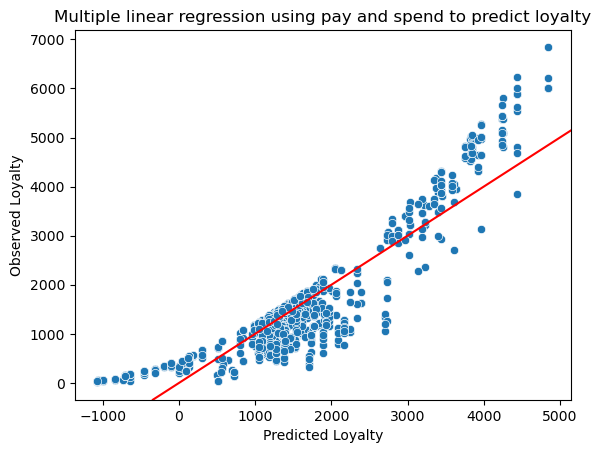

In [31]:
# Create a scatter plot of predicted vs observed loyalty for model6.
sns.scatterplot(data=m4plot, x='Predicted Loyalty', y='Observed Loyalty')\
.set_title('Multiple linear regression using pay and spend to predict loyalty')

plt.axline([0, 0], slope=1, color='red');

plt.savefig('loyalty.png')

- There is an issue with non-linearity in the residuals of this model. It underpredicts loyalty at low and high values of loyalty.

## Train and test the loyalty MLR model

In [32]:
# Split the data in 'train' (80%) and 'test' (20%) sets. Training needs to be as large as possible.
# 80/20 or 70/30 is a useful rule of thumb.
# This guards against over-fitting.
X_train, X_test, Y_train, Y_test = sklearn.model_selection.train_test_split(X, y,
                                                                            test_size = 0.20,
                                                                            random_state = 42)

In [33]:
# Training the model using the 'statsmodel' OLS library.
# Fit the model with the added constant to take account of intercept term.
model = sm.OLS(Y_train, sm.add_constant(X_train)).fit()

# Set the predicted response vector.
Y_pred = model.predict(sm.add_constant(X_test)) 

# Call a summary of the model.
print_model = model.summary()

# Print the summary.
print(print_model)  

                            OLS Regression Results                            
Dep. Variable:                loyalty   R-squared:                       0.830
Model:                            OLS   Adj. R-squared:                  0.830
Method:                 Least Squares   F-statistic:                     3895.
Date:                Sun, 05 Oct 2025   Prob (F-statistic):               0.00
Time:                        19:42:29   Log-Likelihood:                -12307.
No. Observations:                1600   AIC:                         2.462e+04
Df Residuals:                    1597   BIC:                         2.464e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1700.3237     39.588    -42.950      0.0

In [34]:
# Run a regression test.
# Specify the model.
mlr = LinearRegression()  

# Fit the model. We can only fit the model with the training data set.
mlr.fit(X_train, Y_train)

LinearRegression()

In [35]:
# Call the predictions for X in the test set.
y_pred_mlr = mlr.predict(X_train)  

# Print the predictions.
print("Prediction for test set: {}".format(y_pred_mlr))

Prediction for test set: [1630.49111009  512.07788432 2146.32624449 ... 1422.83416662 1259.61480693
 1441.17214231]


In [36]:
# Call the predictions for X in the test set.
y_pred_mlr = mlr.predict(X_test)  

# Print the predictions.
print("Prediction for test set: {}".format(y_pred_mlr))  

Prediction for test set: [ -725.11711735  2976.65149188  2644.50590347  1416.28990278
  1434.2479047   1535.45165243   709.53845826  1358.38381754
  1577.07452533  3212.92022784  1170.66219209  1588.48826342
  1589.70563198  2360.07003078  1201.63127443  1582.78139438
  1642.74224297   657.71921584  -106.10091912  -833.24510268
  1354.27429082  -188.12929636  1754.52233399  1256.34267501
  1422.83416662  1616.64263488  3855.98127081  1541.53849524
  1742.27120111  1956.16988192   128.11305348   859.2893165
  1075.54528717  1575.01976198  1484.84977857  1179.64119305
   979.28846095  1756.19712359  1517.4936505    979.28846095
  1217.15453924  1577.07452533  1440.79216854  4253.41460309
  4257.06670877  -454.98714089  1575.01976198  1434.2479047
  1474.65340904  1468.94654     1548.46273285   960.11309046
   796.89373078  -647.57824059  1640.30750585  1527.31004626
   311.72515222  3974.30562567  1548.46273285  3233.31296689
  1306.94454888  1517.4936505   1283.27967791  1434.2479047
  

In [37]:
# Print the R-squared value expressed as a % rounded to 4 sig figs.
print(round(mlr.score(X_test, Y_test)*100, 4))

81.4424


- When applied to the test set, the model built using the train set explains 81% of the variance. This suggests spend and pay are both strong predictors of loyalty, and they do not appear to be correlated with each other - but we will check this by testing for multicollinearity, measuring the VIF (Variance Inflation Factor):

## Check for multicollinearity by measuring the VIF (Variance Inflation Factor)

In [38]:
# Check multicollinearity.
x_temp = sm.add_constant(X_train)

# Create an empty DataFrame. 
vif = pd.DataFrame()

# Calculate the VIF for each value.
vif['VIF Factor'] = [variance_inflation_factor(x_temp.values,
                                               i) for i in range(x_temp.values.shape[1])]

# Create the feature columns.
vif['features'] = x_temp.columns

# Print the values to one decimal points.
print(vif.round(2))

   VIF Factor features
0        8.91    const
1        1.00    spend
2        1.00      pay


- VIF values of 1 indicate that there is no multicollinearity - this is good news!

## Evaluate the model

In [39]:
# Call the ‘metrics.mean_absolute_error’ function.  
print('Mean Absolute Error (Final):', metrics.mean_absolute_error(Y_test, Y_pred))  

# Call the ‘metrics.mean_squared_error’ function.
print('Mean Square Error (Final):', metrics.mean_squared_error(Y_test, Y_pred)) 

Mean Absolute Error (Final): 429.6636201690913
Mean Square Error (Final): 300944.0917834269


## Test for homoscedasticity with the Breusch-Pagan test

In [40]:
# Run the OLS model on the data.
f = 'y ~ X'

test = ols(f, data = reviews).fit()

# Run the Breusch-Pagan test function on the model residuals and x-variables.
test = sms.het_breuschpagan(test.resid, test.model.exog) 

# Print the results of the Breusch-Pagan test.
terms = ['LM stat', 'LM Test p-value', 'F-stat', 'F-test p-value']
print(dict(zip(terms, test)))

{'LM stat': 53.72656673047227, 'LM Test p-value': 2.1548858465031367e-12, 'F-stat': 27.563432744523077, 'F-test p-value': 1.55452636297145e-12}


 - The p value for the F-test is <0.05 so we reject the null hypothesis - we cannot assume homoscedascity and the variance is uneven. This undermines the robustness of the model.

# Week 1 Summary of Regression Analysis:

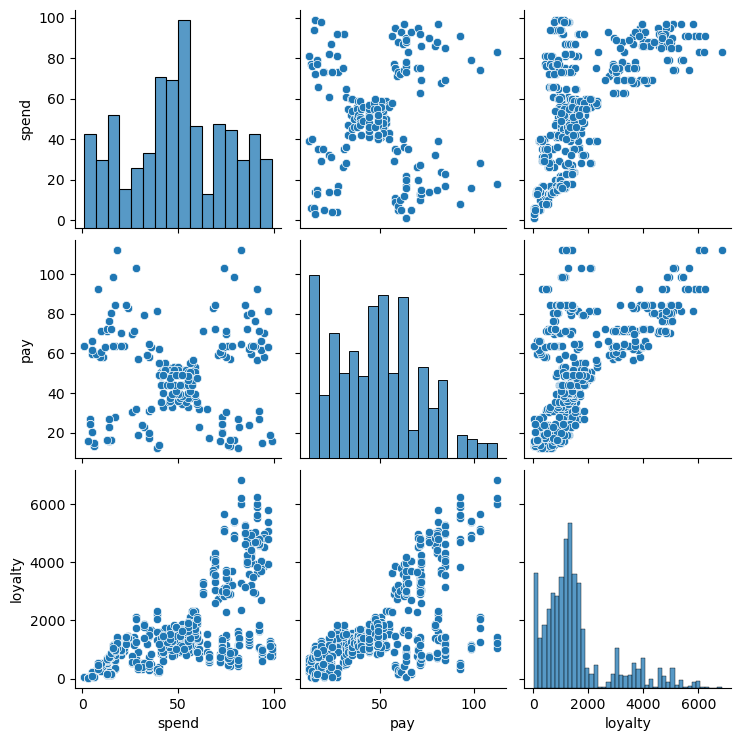

In [41]:
# Plot scatterplots for assignment report on regression analysis.
# These will illustrate the relationship between the variables in the MLR model.
sns.pairplot(reviews[['spend', 'pay', 'loyalty']]);

plt.savefig('loyalty_predictors.png')

**Observations:**
- The model with the highest R-squared value (83%) was the multiple linear regression, which used spend and pay as predictors of loyalty (model4). However, this relationship is undermined by heteroscedasticity in the data, as indicated by the Breusch-Pagan test.

# Week 2 assignment: Exploring the structure using decision trees.

The team wants you to use decision trees to attempt to better understand the structure found in the data. You need to grow and prune a decision tree regressor and then visualise and interpret the output.
Make sure to comment on the potential usefulness in decision-making processes and your observations regarding the model.

## Instructions
1. Prepare the data for creating your decision tree. 
    1. Import the CSV file you have prepared in Week 1.
    2. Create a new DataFrame with the appropriate columns.
        1. Specify that loyalty points is the target variable (Y) and should be excluded from your input data.
        2. Specify X for the independent variables and y as the dependent variable. Therefore, df\[cols\] will be the independent variables and the column containing loyalty points the dependent variable.
        3. Explore the new DataFrame. 
2. Split the data set into a train and test sets for both X and y at a 70:30 ratio. As previously, random_state=42.
3. Create a decision tree regressor to explore the impact of other features on the loyalty points.
    1. Import the DecisionTreeRegressor class from the sklearn.tree library. 
    2. Create a variable (e.g. regressor) to store the DecisionTreeRegressor() class. (As previously, random_state=42.).
    3. Fit the regressor object to the data set with the fit() function.
    4. Remember to prune your tree using basic pruning strategies and compare the performance before and after applying the pruning strategy.
    5. Plot the final decision tree.
4. Fit a final model and interpret the output.
    1. Justify your selection of pruning strategy implemented and interpret the output.
    2. Evaluate the usefulness of the obtained result and interpret the tree and how it could be used to inform business decisions in the organisation.
5. Summarise (150–200 words) the most important business insights, anything you would like to explore further, and suggested future actions.
 
Back up your work to a safe location. This will allow you to revert to a previous state in the case of making a mistake in the code or deleting a section by mistake. (A simple way of doing this is to save or email a compressed version to yourself at frequent intervals.)


## 1. Load and prepare the data

In [42]:
# Import all the necessary packages
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree 
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import statsmodels.api as sm
import warnings
import matplotlib.pyplot as plt

# Settings for the notebook.
warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize'] = [15, 10]

In [43]:
# Create your new DataFrame.
df2 = pd.read_csv('turtle_reviews_clean.csv')

df2.head()

,Unnamed: 0,gender,age,pay,spend,loyalty,education,product,review,summary
0,0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap


In [44]:
# Specify columns for df2 Dataframe
cols = df2.columns[df2.columns != 'loyalty']


In [45]:
# Specify Y.
y = df2['loyalty']
# Specify X.
X = df2[['spend', 'pay']]

In [46]:
# Review X
X.head()

,spend,pay
0,39,12.30
1,81,12.30
2,6,13.12
3,77,13.12
4,40,13.94


In [47]:
# Review y
y.head()

0    210
1    524
2     40
3    562
4    366
Name: loyalty, dtype: int64

## 2. Create train and test data sets.

In [48]:
# Split the data into test and train data.
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = 0.3, 
                                                    random_state = 42)

In [49]:
# Import the 'DecisionTreeRegressor' class from sklearn.
from sklearn.tree import DecisionTreeRegressor 

## 3. Create Decision tree regressor

In [50]:
# Create your decision tree regressor.
# Create the 'DecisionTreeRegressor' class 
# (which has many parameters; input only #random_state=0).
regressor = DecisionTreeRegressor(random_state=42)

In [51]:
# Evaluate the model.
regressor.fit(X_train,y_train)

DecisionTreeRegressor(random_state=42)

In [52]:
# Predict the response for the data test.
y_predict = regressor.predict(X_test)  

# predict on test data and evaluate performance before pruning
print("Before pruning:")
print("MSE:", mean_squared_error(y_test, y_predict))
print("R2 Score:", r2_score(y_test, y_predict))

Before pruning:
MSE: 26097.98366433656
R2 Score: 0.9838881140581562


In [53]:
# Prune the model.
# Apply basic pruning (limit tree depth and min_samples_leaf)
pruned_regressor = DecisionTreeRegressor(
    random_state=42,
    max_depth=3,            # maximum depth of tree
    min_samples_leaf=5      # minimum samples per leaf
)
pruned_regressor.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=3, min_samples_leaf=5, random_state=42)

In [54]:
# Evaluate after pruning
y_predict_pruned = pruned_regressor.predict(X_test)

print("\nAfter pruning:")
print("MSE:", mean_squared_error(y_test, y_predict_pruned))
print("R2 Score:", r2_score(y_test, y_predict_pruned))


After pruning:
MSE: 137962.67325147352
R2 Score: 0.9148271803581075


## 4. Fit and plot final model.

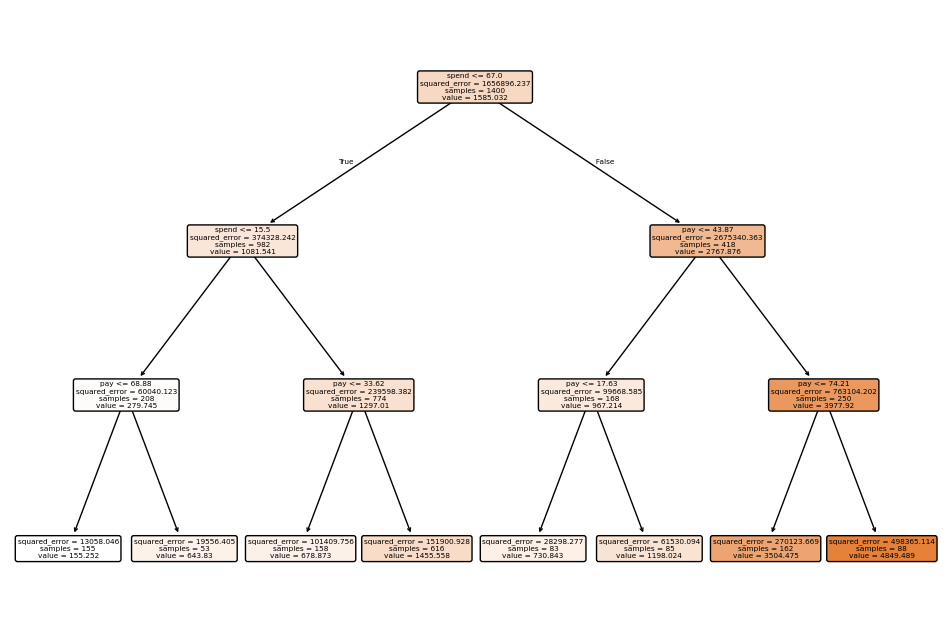

In [55]:
# Fit and plot final model.
plt.figure(figsize=(12, 8))
plot_tree(
    pruned_regressor,           # Fitted pruned tree.
    feature_names=X.columns,    # Names of the independent variables
    filled=True,                # Color by value
    rounded=True                # Rounded boxes
)

plt.savefig('PrunedFinalDecisionTree.png')
plt.show()

## 5. Discuss: Insights and observations


**Interpretation of Model:**
- Spend is the strongest predictor of loyalty points; pay refines predictions within spending segments.

- Leaves show average loyalty points for customer segments; pruning ensures each leaf is reliable.

- The pruned tree balances simplicity and predictive accuracy, avoiding overfitting while remaining interpretable.

**Observations (Business/Practical):**
- High-spending customers consistently earn higher loyalty points, making them prime targets for retention strategies.

- Mid-tier spenders can be incentivised with targeted offers to increase engagement.

- Payment behaviour subtly influences loyalty, suggesting opportunities for tailored promotions.

- The model provides clear, actionable segments for loyalty program optimisation.

- Adding more features (e.g., purchase frequency, product categories) could capture additional patterns and improve decision-making.

## Bottom Line
The decision tree provides a practical, easy-to-interpret model that helps the organisation optimise loyalty programs, target marketing campaigns effectively, and allocate resources where they maximise customer engagement.

# Create a Random Forest

## 1. Load and Prepare Data

In [56]:
# Load and prepare data
turtle = pd.read_csv('turtle_reviews_clean.csv')
turtle = turtle.drop('Unnamed: 0', axis=1)

# View DataFrame
turtle

,gender,age,pay,spend,loyalty,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap
...,...,...,...,...,...,...,...,...,...
1995,Female,37,84.46,69,4031,PhD,977,The perfect word game for mixed ages (with Mom...,The perfect word game for mixed ages (with Mom
1996,Female,43,92.66,8,539,PhD,979,Great game. Did not think I would like it whe...,Super fun
1997,Male,34,92.66,91,5614,graduate,1012,Great game for all.........\nKeeps the mind ni...,Great Game
1998,Male,34,98.40,16,1048,PhD,1031,fun game!,Four Stars


In [57]:
# Define features and target variable
X = turtle.drop(['loyalty', 'review', 'summary'], axis=1)
y = turtle['loyalty']

In [58]:
# Encode categorical variables
for col in ['gender', 'education']:
    X[col] = LabelEncoder().fit_transform(X[col])

In [59]:
# Split data (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [60]:
# Train model
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_jobs=-1, random_state=42)

In [61]:
# Predictions
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

In [62]:
# Evaluation metrics
print("Training Set:")
print(f"  R² Score: {r2_score(y_train, y_train_pred):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.2f}")
print(f"  MAE: {mean_absolute_error(y_train, y_train_pred):.2f}")

print("\nTest Set:")
print(f"  R² Score: {r2_score(y_test, y_test_pred):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.2f}")
print(f"  MAE: {mean_absolute_error(y_test, y_test_pred):.2f}")

Training Set:
  R² Score: 0.9982
  RMSE: 55.20
  MAE: 27.82

Test Set:
  R² Score: 0.9947
  RMSE: 92.39
  MAE: 46.07


In [63]:
# Feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nFeature Importance:")
print(importance_df)


Feature Importance:
     Feature  Importance
3      spend    0.499975
2        pay    0.482842
1        age    0.014528
5    product    0.001370
4  education    0.000840
0     gender    0.000445


In [64]:
# Prediction accuracy
errors = np.abs(y_test - y_test_pred)
print(f"\nPredictions within ±100 points: {(errors <= 100).sum() / len(y_test) * 100:.2f}%")
print(f"Predictions within ±200 points: {(errors <= 200).sum() / len(y_test) * 100:.2f}%")


Predictions within ±100 points: 84.67%
Predictions within ±200 points: 95.50%


## Model Performance Excellence
- The Random Forest model achieves exceptional predictive accuracy with an R² score of 0.9947, explaining 99.47% of the variance in customer loyalty points.
- With an RMSE of 92.74 points and MAE of 46.10 points, the model demonstrates highly reliable predictions, with 84.17% of predictions falling within ±100 points and 95.67% within ±200 points.

## Model Patterns and Observations
1. Spending score (spend) accounts for 50% of the model importance, while remuneration (pay) contributes to 48.3%. Together, these two factors drive 98.3% of loyalty points accumulation, revealing a clear mathematical relationship between customer financial capacity and loyalty program engagement.
2. The top 25% of loyalty customers display distinct characteristics. Average spending score of 73 (versus 26 for low-value customers), average remuneration of £68.70 (versus £32.97), and average loyalty points of 3,405 (versus 372). These customers represent the most valuable segment, generating approximately 9 times more loyalty engagement than bottom-tier customers.
3. 80% of low-spending customers remain in low loyalty tiers (412 out of 515), while 60% of high-spending customers achieve high loyalty status (346 out of 579). Medium spenders show moderate loyalty, with 78% reaching medium loyalty tiers (707 out of 906), indicating a strong linear progression between spending and loyalty accumulation.

## Business Insights Uncovered by Random Forest Model
1. Prioritise Spending Score Enhancement
   - Implement targeted strategies to increase spending frequency and basket size.
   - Use personalised promotions and tiered reward structures.
   - Focus on spend-based incentives over demographic campaigns.
2. Income-Based Tiering Strategy
   - Create premium membership tiers for higher-income segments (>£68).
   - Offer exclusive benefits aligned with demonstrated loyalty potential.
   - Implement income-sensitive pricing structures.
3. Targeted Customer Retention Programs
   - Focus on 686 low-loyalty customers (34% of customer base).
   - Deploy personalised offers, gamification, and early-access promotions.
   - Use predictive analytics to identify at-risk customers before churn.
4. Optimise Reward Structures
   - Create achievable milestones with immediate rewards.
   - Offer bonus points for spending score progression (e.g., 50→70).

## Summary of Insights and Observations
In this analysis, we explored the relationship between customer spending behaviour (spend and pay) and loyalty points using a Decision Tree Regressor. The dataset was prepared and cleaned, then split into training (30%) and testing (70%) sets. The model was initially fit without restrictions, and then pruned using max_depth=3 and min_samples_leaf=5 to reduce overfitting and improve interpretability.

Evaluation of the model before and after pruning showed that pruning slightly reduced predictive accuracy (MSE and R²) but greatly simplified the tree, making the splits easier to interpret and actionable. The root node indicated that spending is the most influential factor in predicting loyalty points, with higher spending correlating with higher rewards—subsequent splits on pay further refined customer segments, highlighting patterns in payment behaviour that affect loyalty.

From a business perspective, these insights enable targeted strategies. High-spending customers can be prioritised for retention and premium loyalty rewards, while mid-tier spenders can be incentivised to increase engagement through personalised offers. Future exploration could include adding more features such as purchase frequency, product categories, or demographic data, to capture additional behavioural patterns. Overall, the pruned decision tree provides a practical framework to inform marketing efforts and optimise loyalty programs.


# 

# Week 3 assignment: Clustering with *k*-means using Python

The marketing department also wants to better understand the usefulness of renumeration and spending scores but do not know where to begin. You are tasked to identify groups within the customer base that can be used to target specific market segments. Use *k*-means clustering to identify the optimal number of clusters and then apply and plot the data using the created segments.

## Instructions
1. Prepare the data for clustering. 
    1. Import the CSV file you have prepared in Week 1.
    2. Create a new DataFrame (e.g. `df3`) containing the `renumeration` and `spending_score` columns.
    3. Explore the new DataFrame. 
2. Plot the renumeration versus spending score.
    1. Create a scatterplot.
    2. Create a pairplot.
3. Use the Silhouette and Elbow methods to determine the optimal number of clusters for *k*-means clustering.
    1. Plot both methods and explain how you determine the number of clusters to use.
    2. Add titles and legends to the plot.
4. Evaluate the usefulness of at least three values for *k* based on insights from the Elbow and Silhoutte methods.
    1. Plot the predicted *k*-means.
    2. Explain which value might give you the best clustering.
5. Fit a final model using your selected value for *k*.
    1. Justify your selection and comment on the respective cluster sizes of your final solution.
    2. Check the number of observations per predicted class.
6. Plot the clusters and interpret the model.

## 1. Load and explore the data

In [65]:
# Import necessary libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import cdist

import warnings
warnings.filterwarnings('ignore')

In [66]:
# Load the CSV file(s) as df3.
df3 = pd.read_csv('turtle_reviews_clean.csv')
# View DataFrame.
df3.head()

,Unnamed: 0,gender,age,pay,spend,loyalty,education,product,review,summary
0,0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap


In [67]:
# Drop unnecessary columns.
df3 = reviews[['pay', 'spend']]


# View DataFame.
df3

,pay,spend
0,12.30,39
1,12.30,81
2,13.12,6
3,13.12,77
4,13.94,40
...,...,...
1995,84.46,69
1996,92.66,8
1997,92.66,91
1998,98.40,16


In [68]:
# Explore the data.
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   pay     2000 non-null   float64
 1   spend   2000 non-null   int64  
dtypes: float64(1), int64(1)
memory usage: 46.9 KB


In [69]:
# Descriptive statistics.
df3.describe()

,pay,spend
count,2000.000000,2000.000000
mean,48.079060,50.000000
std,23.123984,26.094702
min,12.300000,1.000000
25%,30.340000,32.000000
50%,47.150000,50.000000
75%,63.960000,73.000000
max,112.340000,99.000000


## 2. Plot

<Axes: xlabel='pay', ylabel='spend'>

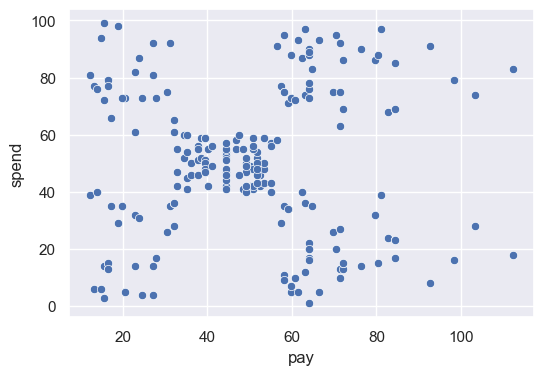

In [70]:
# Create a scatterplot with Seaborn.
sns.set(rc = {'figure.figsize':(6, 4)})
sns.scatterplot(data=df3, x='pay', y='spend')

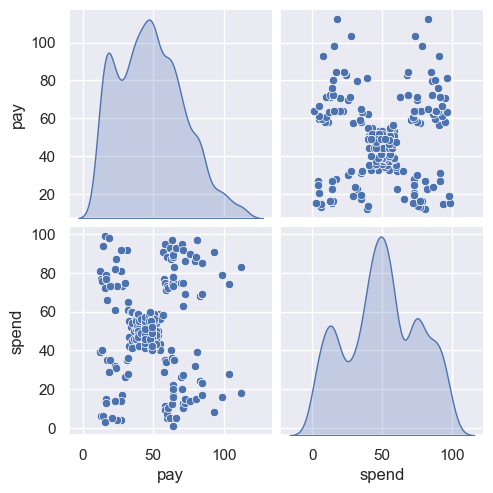

In [71]:
# Create a pairplot with Seaborn.
sns.pairplot(data=df3, diag_kind='kde')

## 3. Elbow and silhoutte methods

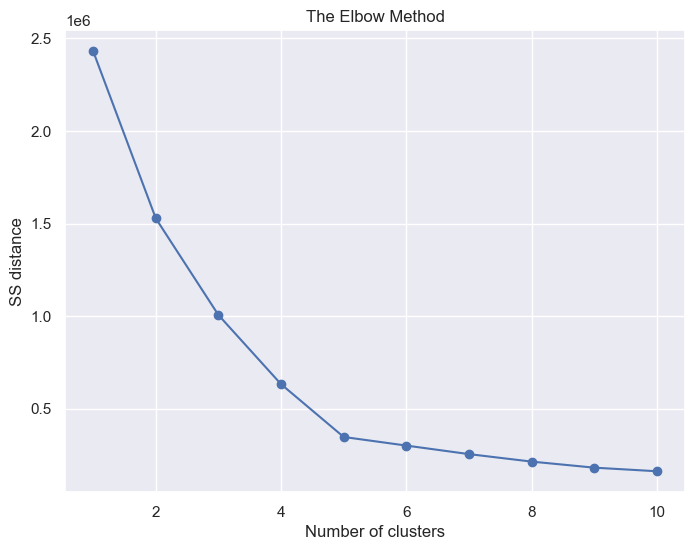

In [72]:
# Determine the number of clusters: Elbow method.
# Elbow method is used to determine the optimal number of clusters for k-means clustering.
ss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i,
                    init='k-means++',
                    max_iter=500,
                    n_init=10,
                    random_state=42)
    kmeans.fit(df3)
    ss.append(kmeans.inertia_)

# Plot the elbow method.
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11),
         ss,
         marker='o')

# Insert labels and title.
plt.title("The Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("SS distance")

plt.savefig('elbow.png')
plt.show()

- The Elbow Method plot suggests that 5 is the most appropriate k value to use - this is where there is a slight but obvious kink in the graph. The scatterplots shown above also strongly suggest that there are five distinct groups of data points.

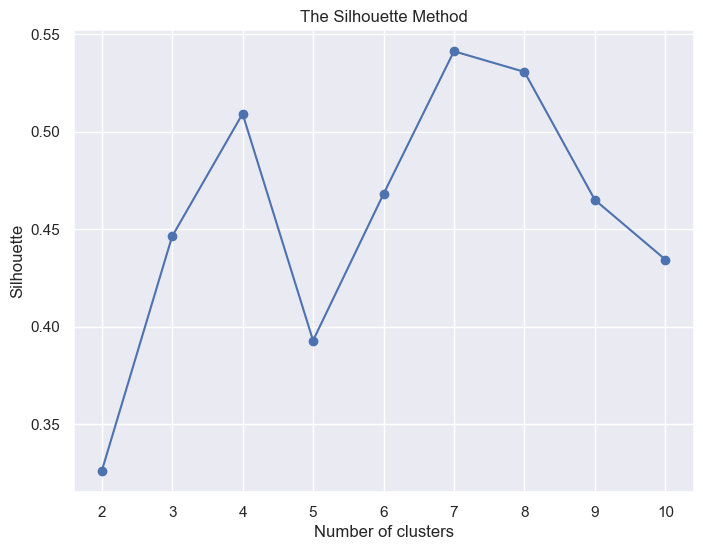

In [73]:
# Determine the number of clusters: Silhouette method.
# Find the range of clusters to be used using the silhouette method.
sil = []
kmax = 10

for k in range(2, kmax+1):
    kmeans_s = KMeans(n_clusters=k).fit(df3)
    labels = kmeans_s.labels_
    sil.append(silhouette_score(df3,
                                labels,
                                metric='euclidean'))

# Plot the silhouette method.
plt.figure(figsize=(8, 6))
plt.plot(range(2, kmax+1),
         sil,
         marker='o')

# Insert labels and title.
plt.title("The Silhouette Method")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette")

plt.savefig('silhouette.png')
plt.show()

- - The silhouette method strongly suggests that 5 is the correct number of cluster as there is an obvious peak in the line plot at k=5. This is supported by the Elbow Method findings, and the scatterplots shown above.

## 4. Evaluate k-means model at different values of *k*

<Figure size 1200x800 with 0 Axes>

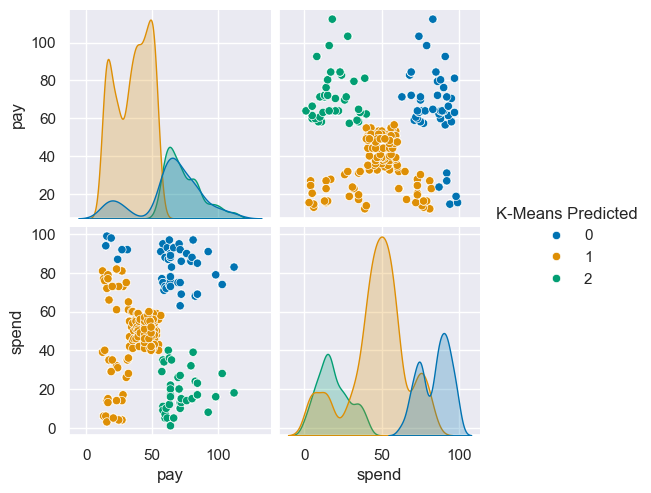

In [74]:
# Use three clusters.
kmeans = KMeans(n_clusters = 3, 
                max_iter = 15000,
                init='k-means++',
                random_state=42).fit(df3)

clusters = kmeans.labels_

df3['K-Means Predicted'] = clusters

# Plot the predicted.
plt.figure(figsize=(12, 8))
sns.pairplot(df3,
             hue='K-Means Predicted',
             diag_kind= 'kde',
            palette='colorblind',
            height = 2.5);

<Figure size 1200x800 with 0 Axes>

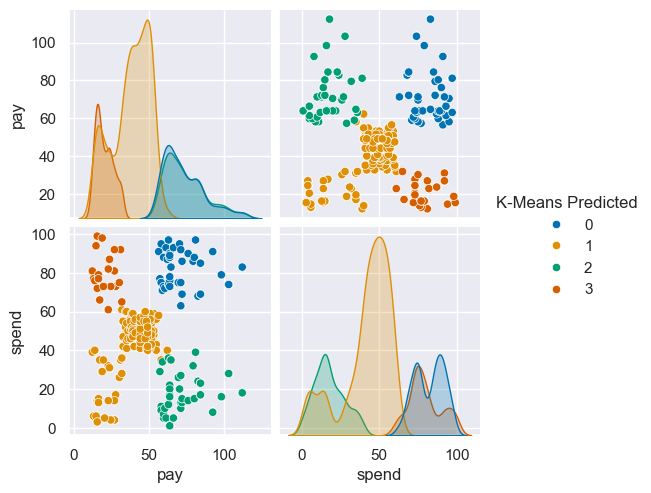

In [75]:
# Use four clusters.
kmeans = KMeans(n_clusters = 4, 
                max_iter = 15000,
                init='k-means++',
                random_state=42).fit(df3)

clusters = kmeans.labels_

df3['K-Means Predicted'] = clusters

# Plot the predicted.
plt.figure(figsize=(12, 8))
sns.pairplot(df3,
             hue='K-Means Predicted',
             diag_kind= 'kde',
            palette='colorblind',
            height = 2.5);

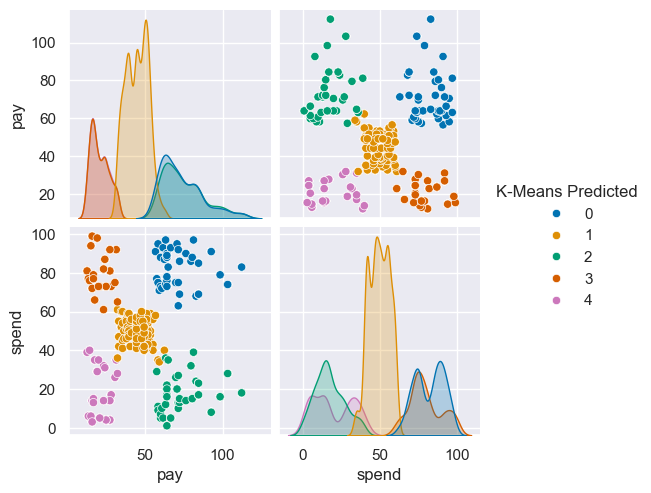

In [76]:
# Use five clusters.
kmeans = KMeans(n_clusters = 5, 
                max_iter = 15000,
                init='k-means++',
                random_state=42).fit(df3)

clusters = kmeans.labels_

df3['K-Means Predicted'] = clusters

# Plot the predicted.
sns.pairplot(df3,
             hue='K-Means Predicted',
             diag_kind= 'kde',
            palette='colorblind');

## 5. Fit final model and justify your choice

- The best model based on the scatterplots, Elbow Method and Silhouette Method is one using five clusters (k=5)

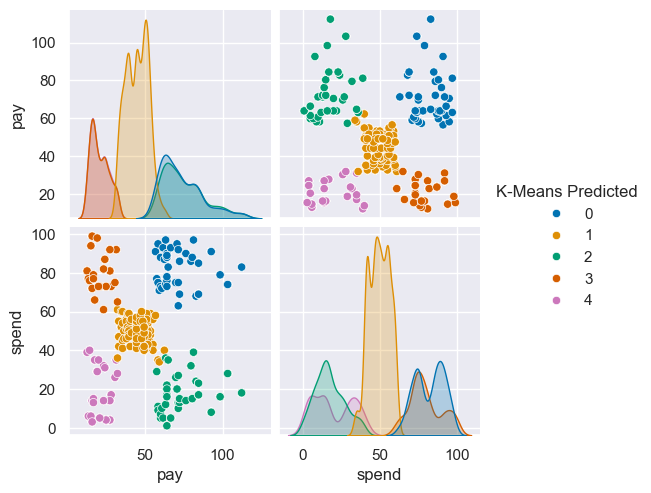

In [77]:
# Apply the final model.
# Use five clusters.
kmeans = KMeans(n_clusters = 5, 
                max_iter = 15000,
                init='k-means++',
                random_state=42).fit(df3)

clusters = kmeans.labels_

df3['K-Means Predicted'] = clusters

# Plot the predicted.
sns.pairplot(df3,
             hue='K-Means Predicted',
             diag_kind= 'kde',
            palette='colorblind');

plt.savefig('SpendvsPay Kclusters.png')
plt.show()

In [78]:
# Check the number of observations per predicted class.
df3['K-Means Predicted'].value_counts()

K-Means Predicted
1    774
0    356
2    330
4    271
3    269
Name: count, dtype: int64

## 6. Plot and interpret the clusters

In [79]:
# Visualising the clusters.
# View the DataFrame.
df3.head(10)

,pay,spend,K-Means Predicted
0,12.30,39,4
1,12.30,81,3
2,13.12,6,4
3,13.12,77,3
4,13.94,40,4
5,13.94,76,3
6,14.76,6,4
7,14.76,94,3
8,15.58,3,4
9,15.58,72,3


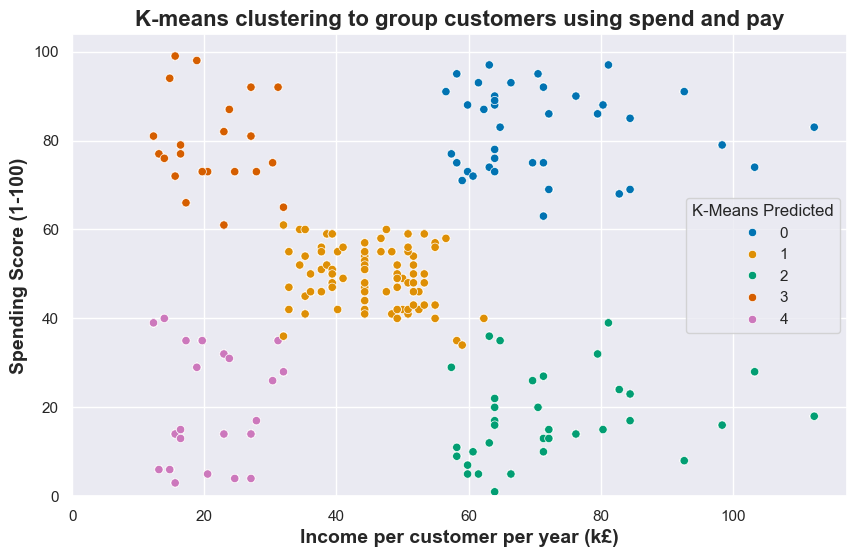

In [80]:
# Visualising the clusters.
# Set plot size.
plt.figure(figsize=(10, 6))
sns.set_style = 'whitegrid'

# Create a scatterplot.
sns.scatterplot(x='pay' , 
                y ='spend',
                data=df3,
                hue='K-Means Predicted',
                palette='colorblind')\
                .set_title('K-means clustering to group customers using spend and pay',
                          fontsize=16, fontweight = 'bold')

plt.xlim(0)
plt.ylim(0)
plt.xlabel('Income per customer per year (k£)', fontsize=14, fontweight = 'bold')
plt.ylabel('Spending Score (1-100)', fontsize=14, fontweight = 'bold')
plt.savefig('clusters.png');
plt.show()

## 7. Discuss: Insights and observations

## Observations:

- The data points clearly form five distinct clusters, and both the Elbow and Silhouette methods suggest 5 as the best value for k in a k-means clustering model. 
- The scatterplot confirms that the five different classes form hard clusters with no overlap.
- This analysis suggests that customers could be grouped according to these clusters, based on their pay and spending score, and these groups could be used in further analyses using other data, such as natural language processing of their reviews, and the types of products they are buying.

## Business Insights:

- K-means clustering identified five distinct customer groups based on income and spending score.

- Cluster 0 (High Income, High Spending): Premium customers, small group, key for loyalty and exclusive offers.

- Cluster 1 (Medium Income, Medium Spending): Largest group, forms the average customer base, good for upselling.

- Cluster 2 (High Income, Low Spending): Wealthy but disengaged, medium-sized group with strong growth potential.

- Cluster 3 (Low Income, High Spending): Smaller group, aspirational buyers, high spend despite low income; higher risk but brand-loyal.

- Cluster 4 (Low Income, Low Spending): Small group, low-value, minimal marketing investment recommended.

- Income and spending do not always correlate (Clusters 2 and 3 show mismatches).

- Future analysis should explore why high-income customers underspend and why low-income customers overspend to refine targeting strategies.

# Week 4 assignment: NLP using Python
Customer reviews were downloaded from the website of Turtle Games. This data will be used to steer the marketing department on how to approach future campaigns. Therefore, the marketing department asked you to identify the 15 most common words used in online product reviews. They also want to have a list of the top 20 positive and negative reviews received from the website. Therefore, you need to apply NLP on the data set.

## Instructions
1. Load and explore the data. 
    1. Sense-check the DataFrame.
    2. You only need to retain the `review` and `summary` columns.
    3. Determine if there are any missing values.
2. Prepare the data for NLP
    1. Change to lower case and join the elements in each of the columns respectively (`review` and `summary`).
    2. Replace punctuation in each of the columns respectively (`review` and `summary`).
    3. Drop duplicates in both columns (`review` and `summary`).
3. Tokenise and create wordclouds for the respective columns (separately).
    1. Create a copy of the DataFrame.
    2. Apply tokenisation on both columns.
    3. Create and plot a wordcloud image.
4. Frequency distribution and polarity.
    1. Create frequency distribution.
    2. Remove alphanumeric characters and stopwords.
    3. Create wordcloud without stopwords.
    4. Identify 15 most common words and polarity.
5. Review polarity and sentiment.
    1. Plot histograms of polarity (use 15 bins) for both columns.
    2. Review the sentiment scores for the respective columns.
6. Identify and print the top 20 positive and negative reviews and summaries respectively.
7. Include your insights and observations.

## 1. Load and explore the data

In [81]:
# Import all the necessary packages.
import pandas as pd
import numpy as np
import nltk 
import os 
import matplotlib.pyplot as plt
import string

# nltk.download ('punkt').
# nltk.download ('stopwords').

from wordcloud import WordCloud
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from nltk.corpus import stopwords
from textblob import TextBlob
from scipy.stats import norm

# Import Counter.
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

In [82]:
# Load the data set as df4.
df4 = pd.read_csv('turtle_reviews_clean.csv')

# View DataFrame.
df4.head()

,Unnamed: 0,gender,age,pay,spend,loyalty,education,product,review,summary
0,0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap


In [83]:
# Explore data set.
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  2000 non-null   int64  
 1   gender      2000 non-null   object 
 2   age         2000 non-null   int64  
 3   pay         2000 non-null   float64
 4   spend       2000 non-null   int64  
 5   loyalty     2000 non-null   int64  
 6   education   2000 non-null   object 
 7   product     2000 non-null   int64  
 8   review      2000 non-null   object 
 9   summary     2000 non-null   object 
dtypes: float64(1), int64(5), object(4)
memory usage: 156.4+ KB


In [84]:
df4.describe()

,Unnamed: 0,age,pay,spend,loyalty,product
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,999.500000,39.495000,48.079060,50.000000,1578.032000,4320.521500
std,577.494589,13.573212,23.123984,26.094702,1283.239705,3148.938839
min,0.000000,17.000000,12.300000,1.000000,25.000000,107.000000
25%,499.750000,29.000000,30.340000,32.000000,772.000000,1589.250000
50%,999.500000,38.000000,47.150000,50.000000,1276.000000,3624.000000
75%,1499.250000,49.000000,63.960000,73.000000,1751.250000,6654.000000
max,1999.000000,72.000000,112.340000,99.000000,6847.000000,11086.000000


In [85]:
# Keep necessary columns. Drop unnecessary columns.
df4 = reviews[['review', 'summary']]

# View DataFrame.
df4

,review,summary
0,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,As my review of GF9's previous screens these w...,Money trap
...,...,...
1995,The perfect word game for mixed ages (with Mom...,The perfect word game for mixed ages (with Mom
1996,Great game. Did not think I would like it whe...,Super fun
1997,Great game for all.........\nKeeps the mind ni...,Great Game
1998,fun game!,Four Stars


In [86]:
# Determine if there are any missing values.
df4.isna().any().any()

False

## 2. Prepare the data for NLP
### 2a) Change to lower case and join the elements in each of the columns respectively (review and summary)

In [87]:
# Review: Change all to lower case and join with a space.
df4['review'] = (df4['review'].str.lower().str.replace(f"[{string.punctuation}]", " ", regex=True))

In [88]:
# Summary: Change all to lower case and join with a space.
df4['summary'] = (df4['summary'].str.lower().str.replace(f"[{string.punctuation}]", " ", regex=True))

In [89]:
df4['review'] = (
    df4['review']
    .str.lower()
    .str.replace(f"[{string.punctuation}]", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [90]:
df4['summary'] = (
    df4['summary']
    .str.lower()
    .str.replace(f"[{string.punctuation}]", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [91]:
df4.head()

,review,summary
0,when it comes to a dm s screen the space on th...,the fact that 50 of this space is wasted on ar...
1,an open letter to galeforce9 your unpainted mi...,another worthless dungeon master s screen from...
2,nice art nice printing why two panels are fill...,pretty but also pretty useless
3,amazing buy bought it as a gift for our new dm...,five stars
4,as my review of gf9 s previous screens these w...,money trap


### 2b) Replace punctuation in each of the columns respectively (review and summary)

In [92]:
# Import the necessary module to remove punctuation.
# import re (added to the very start of all import packages)

In [93]:
# Replace all the punctuations in review column.
df4['review'] = [re.sub('[^\w\s]+', '', s) for s in df4['review'].tolist()]

# View output.
df4.head()

,review,summary
0,when it comes to a dm s screen the space on th...,the fact that 50 of this space is wasted on ar...
1,an open letter to galeforce9 your unpainted mi...,another worthless dungeon master s screen from...
2,nice art nice printing why two panels are fill...,pretty but also pretty useless
3,amazing buy bought it as a gift for our new dm...,five stars
4,as my review of gf9 s previous screens these w...,money trap


In [94]:
# Replace all the puncuations in summary column.
df4['summary'] = [re.sub('[^\w\s]+', '', s) for s in df4['summary'].tolist()]

# View output.
df4.head()

,review,summary
0,when it comes to a dm s screen the space on th...,the fact that 50 of this space is wasted on ar...
1,an open letter to galeforce9 your unpainted mi...,another worthless dungeon master s screen from...
2,nice art nice printing why two panels are fill...,pretty but also pretty useless
3,amazing buy bought it as a gift for our new dm...,five stars
4,as my review of gf9 s previous screens these w...,money trap


### 2c) Drop duplicates in both columns

In [95]:
# Drop duplicates in both columns.
# df4 = df4.drop_duplicates(subset=['review', 'summary']).reset_index(drop=True)

# View DataFrame.
df4.shape

(2000, 2)

- The above code was written to remove duplicates but the decision was taken to leave the duplicates in becuase it is plausible that they were written by different customers. They are generic in nature and in some cases have different capitalisation, also suggesting different authors.

## 3. Tokenise and create wordclouds

In [96]:
# Create new DataFrame (copy DataFrame).
df5 = df4.copy()

# View DataFrame.
df5

,review,summary
0,when it comes to a dm s screen the space on th...,the fact that 50 of this space is wasted on ar...
1,an open letter to galeforce9 your unpainted mi...,another worthless dungeon master s screen from...
2,nice art nice printing why two panels are fill...,pretty but also pretty useless
3,amazing buy bought it as a gift for our new dm...,five stars
4,as my review of gf9 s previous screens these w...,money trap
...,...,...
1995,the perfect word game for mixed ages with mom ...,the perfect word game for mixed ages with mom
1996,great game did not think i would like it when ...,super fun
1997,great game for all keeps the mind nimble,great game
1998,fun game,four stars


In [97]:
# Apply tokenisation to the review column
df5['review_tokens'] = df5['review'].apply(word_tokenize)

# Preview the data.
df5['review_tokens'].head()

0    [when, it, comes, to, a, dm, s, screen, the, s...
1    [an, open, letter, to, galeforce9, your, unpai...
2    [nice, art, nice, printing, why, two, panels, ...
3    [amazing, buy, bought, it, as, a, gift, for, o...
4    [as, my, review, of, gf9, s, previous, screens...
Name: review_tokens, dtype: object

In [98]:
# Apply tokenisation to the summary column
df5['summary_tokens'] = df5['summary'].apply(word_tokenize)

# Preview the data.
df5['summary_tokens'].head()

0    [the, fact, that, 50, of, this, space, is, was...
1    [another, worthless, dungeon, master, s, scree...
2                 [pretty, but, also, pretty, useless]
3                                        [five, stars]
4                                        [money, trap]
Name: summary_tokens, dtype: object

In [99]:
df5.head()

,review,summary,review_tokens,summary_tokens
0,when it comes to a dm s screen the space on th...,the fact that 50 of this space is wasted on ar...,"[when, it, comes, to, a, dm, s, screen, the, s...","[the, fact, that, 50, of, this, space, is, was..."
1,an open letter to galeforce9 your unpainted mi...,another worthless dungeon master s screen from...,"[an, open, letter, to, galeforce9, your, unpai...","[another, worthless, dungeon, master, s, scree..."
2,nice art nice printing why two panels are fill...,pretty but also pretty useless,"[nice, art, nice, printing, why, two, panels, ...","[pretty, but, also, pretty, useless]"
3,amazing buy bought it as a gift for our new dm...,five stars,"[amazing, buy, bought, it, as, a, gift, for, o...","[five, stars]"
4,as my review of gf9 s previous screens these w...,money trap,"[as, my, review, of, gf9, s, previous, screens...","[money, trap]"


In [100]:
# Put all the review tokens into one list.
# Define an empty list of tokens.
all_review_tokens = []

for i in range(df5.shape[0]):
    # Add each token to the list.
    all_review_tokens = all_review_tokens + df5['review_tokens'][i]
    
# Print the length of the list of review tokens.
print("There are",len(all_review_tokens),"review tokens.")

There are 115334 review tokens.


In [101]:
# Put all the summary tokens into one list.
# Define an empty list of tokens.
all_summary_tokens = []

for i in range(df5.shape[0]):
    # Add each token to the list.
    all_summary_tokens = all_summary_tokens + df5['summary_tokens'][i]
    
# Print the length of the list of review tokens.
print("There are",len(all_summary_tokens),"summary tokens.")

There are 9564 summary tokens.


In [102]:
# Convert list of tokens into a string variable.
# Define an empty string variable.
review_tokens_string = ''

for value in all_review_tokens:
    # Add each filtered token word to the string.
    review_tokens_string = review_tokens_string + value + ' '

In [103]:
# Review: Create a word cloud.
review_text = " ".join(df5['review'])
wordcloud_review = WordCloud(width = 1600, height = 900, 
                background_color ='white', 
                colormap='plasma',
                stopwords = 'none',
                min_font_size = 10).generate(review_text)

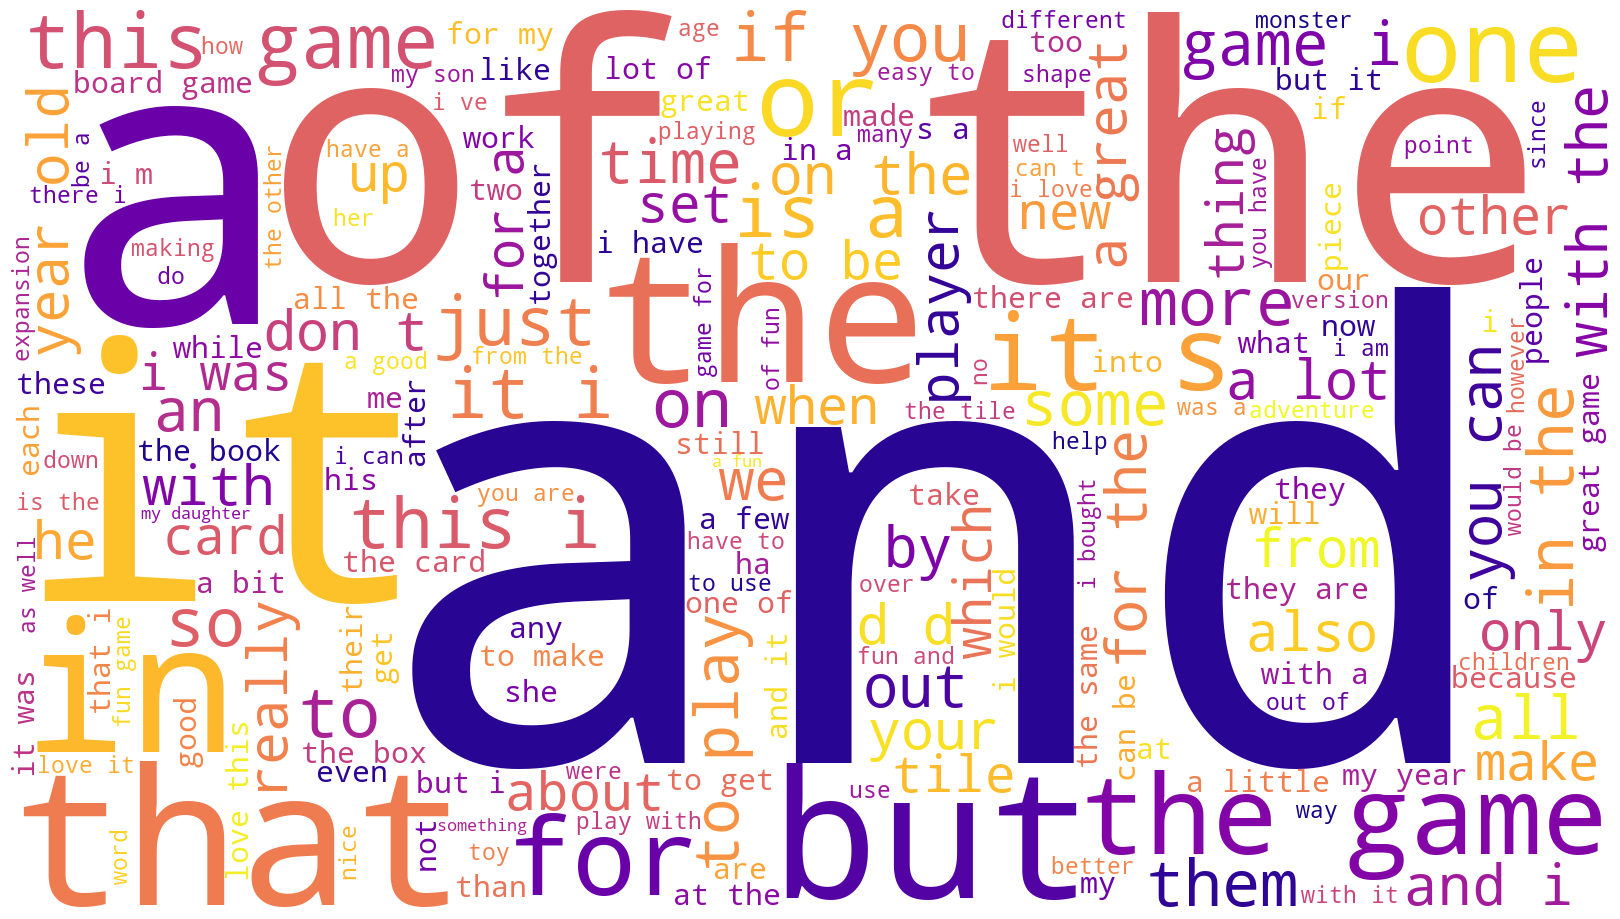

In [104]:
# Review: Plot the WordCloud image.
plt.figure(figsize = (16, 9), facecolor = None) 
plt.imshow(wordcloud_review) 
plt.axis('off') 
plt.tight_layout(pad = 0) 
plt.show()

In [105]:
# Summary: Create a word cloud.
summary_text = " ".join(df5['summary'])
wordcloud_summary = WordCloud(width = 1600, height = 900, 
                background_color ='white', 
                colormap='plasma',
                stopwords = 'none',
                min_font_size = 10).generate(summary_text)

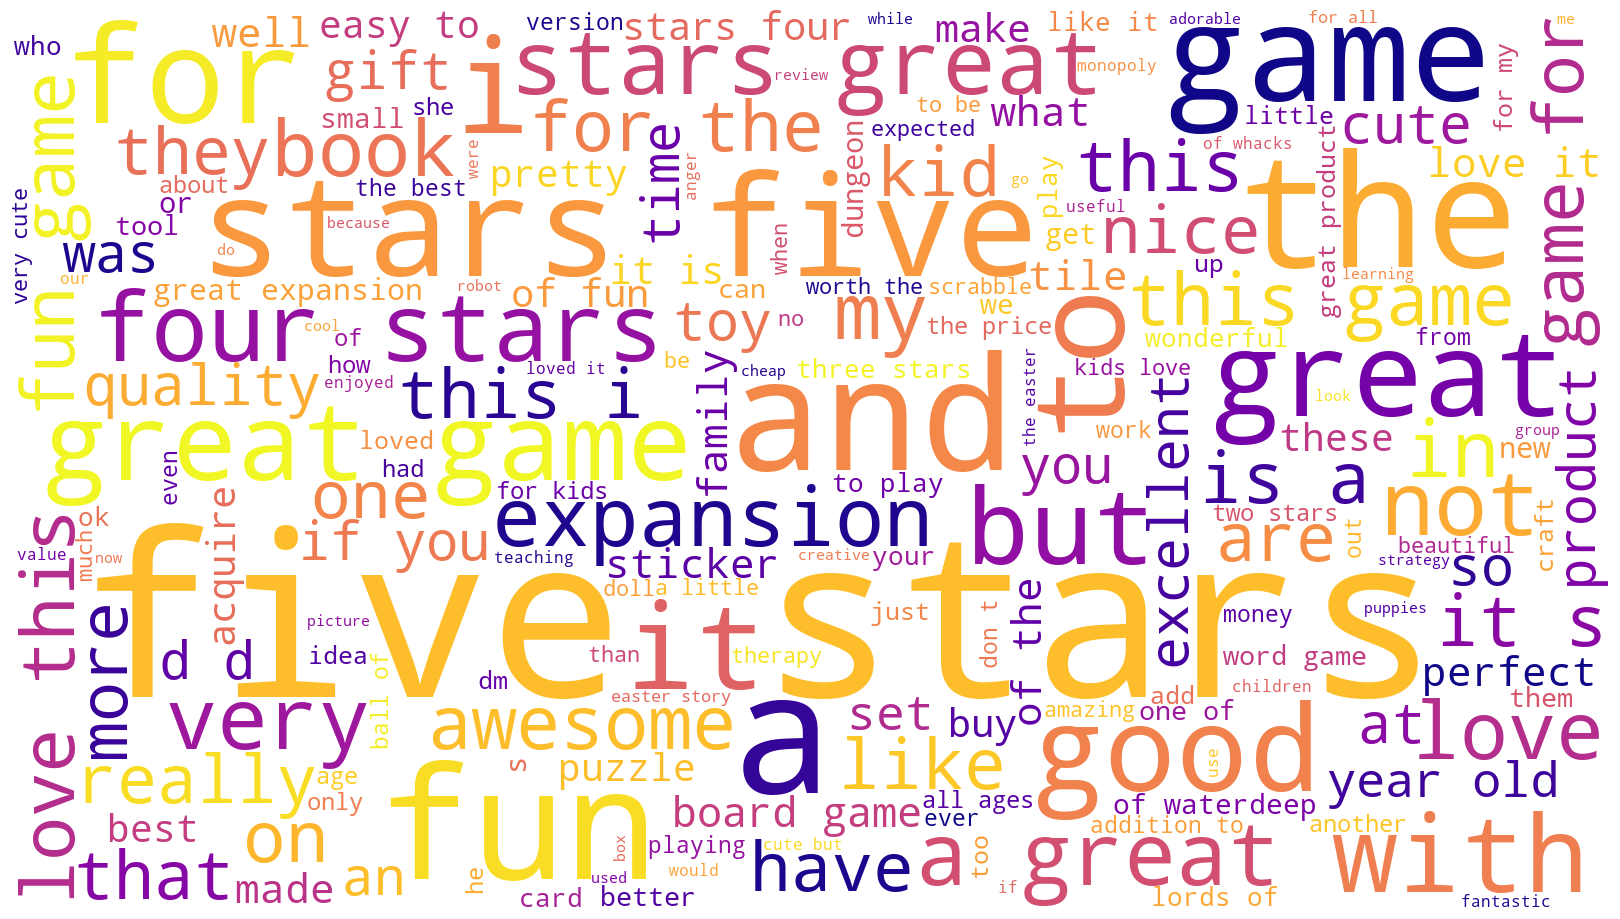

In [106]:
# Summary: Plot the WordCloud image.
plt.figure(figsize = (16, 9), facecolor = None) 
plt.imshow(wordcloud_summary) 
plt.axis('off') 
plt.tight_layout(pad = 0) 
plt.show()

## 4. Frequency distribution and polarity
### 4a) Create frequency distribution

In [107]:
# Determine the frequency distribution.
# Flatten all tokens into one list (for reviews)
all_review_tokens = [word for tokens in df5['review_tokens'] for word in tokens]
# Calculate the frequency distribution.
fdist_review = FreqDist(all_review_tokens)

# Preview data.
fdist_review

FreqDist({'the': 5464, 'and': 3253, 'a': 3191, 'to': 3171, 'of': 2499, 'it': 2496, 'i': 2356, 'is': 1783, 'this': 1781, 'game': 1713, ...})

In [108]:
# Determine the frequency distribution.
# Flatten all tokens into one list (for reviews)
all_summary_tokens = [word for tokens in df5['summary_tokens'] for word in tokens]
# Calculate the frequency distribution.
fdist_summary = FreqDist(all_summary_tokens)

# Preview data.
fdist_summary

FreqDist({'stars': 466, 'five': 381, 'game': 319, 'great': 296, 'the': 262, 'a': 242, 'for': 232, 'fun': 218, 'to': 193, 'it': 185, ...})

### 4b) Remove alphanumeric characters and stopwords

In [109]:
# Remove all the stopwords
# Create a set of English stopwords.
english_stopwords = set(stopwords.words('english'))

In [110]:
# Create a filtered list of all_review_tokens without stopwords.
review_no_sw = [x for x in all_review_tokens if x.lower() not in english_stopwords]

# Re-calculate the frequency distribution of review tokens without stopwords.
fdist_review2 = FreqDist(review_no_sw)

# Preview data.
fdist_review2

FreqDist({'game': 1713, 'great': 598, 'fun': 558, 'one': 540, 'play': 509, 'like': 421, 'love': 332, 'get': 320, 'really': 319, 'cards': 306, ...})

In [111]:
# Create a filtered list of all_summary_tokens without stopwords.
summary_no_sw = [x for x in all_summary_tokens if x.lower() not in english_stopwords]

# Re-calculate the frequency distribution of review tokens without stopwords.
fdist_summary2 = FreqDist(summary_no_sw)

# Preview data.
fdist_summary2

FreqDist({'stars': 466, 'five': 381, 'game': 319, 'great': 296, 'fun': 218, 'love': 93, 'good': 93, 'four': 58, 'like': 54, 'expansion': 53, ...})

### 4c) Create wordcloud without stopwords

In [112]:
# Create a wordcloud without stop words.
# Convert list of tokens into a string variable.
# Define an empty string variable.
review_tokens_string = ''

for value in review_no_sw:
    # Add each filtered token word to the string.
    review_tokens_string = review_tokens_string + value + ' '

In [113]:
# Review: Create a word cloud.
review_wordcloud = WordCloud(width = 1600, height = 900, 
                background_color ='white', 
                colormap='tab10',
                min_font_size = 10).generate(review_tokens_string)

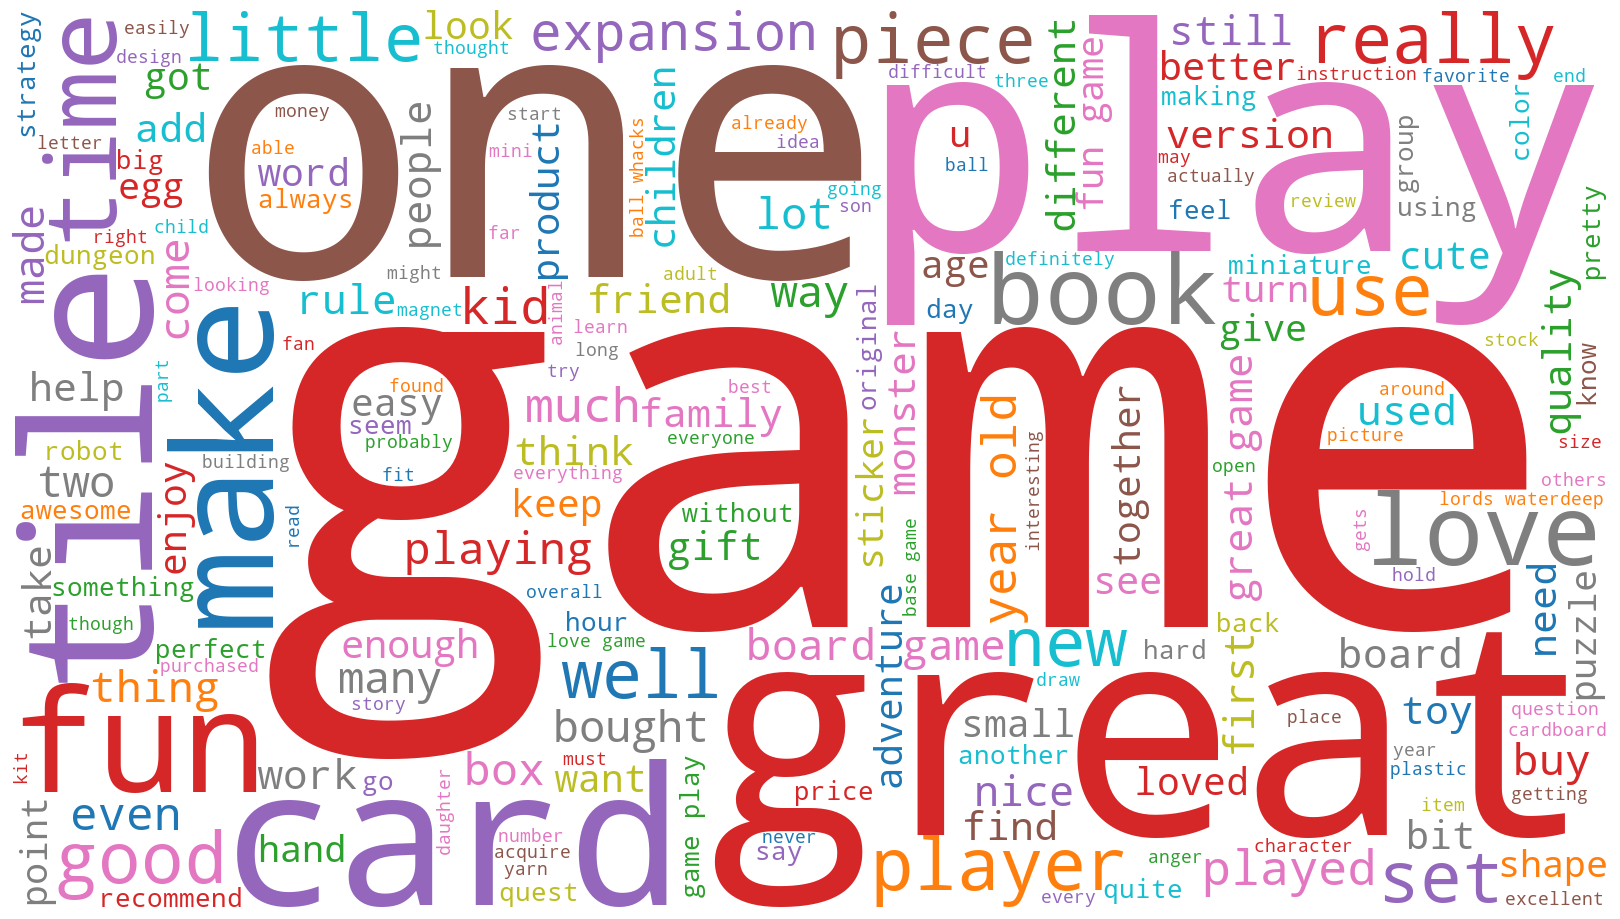

In [114]:
# Plot the wordcloud image from review.
plt.figure(figsize = (16, 9), facecolor = None) 
plt.imshow(review_wordcloud) 
plt.axis('off') 
plt.tight_layout(pad = 0) 

plt.savefig('cloud_review.png')
plt.show()

In [115]:
# Convert list of tokens into a string variable.
# Define an empty string variable.
summary_tokens_string = ''

for value in summary_no_sw:
    # Add each filtered token word to the string.
    summary_tokens_string = summary_tokens_string + value + ' '

In [116]:
# Review: Create a word cloud.
summary_wordcloud = WordCloud(width = 1600, height = 900, 
                background_color ='white', 
                colormap='tab10',
                min_font_size = 10).generate(summary_tokens_string)

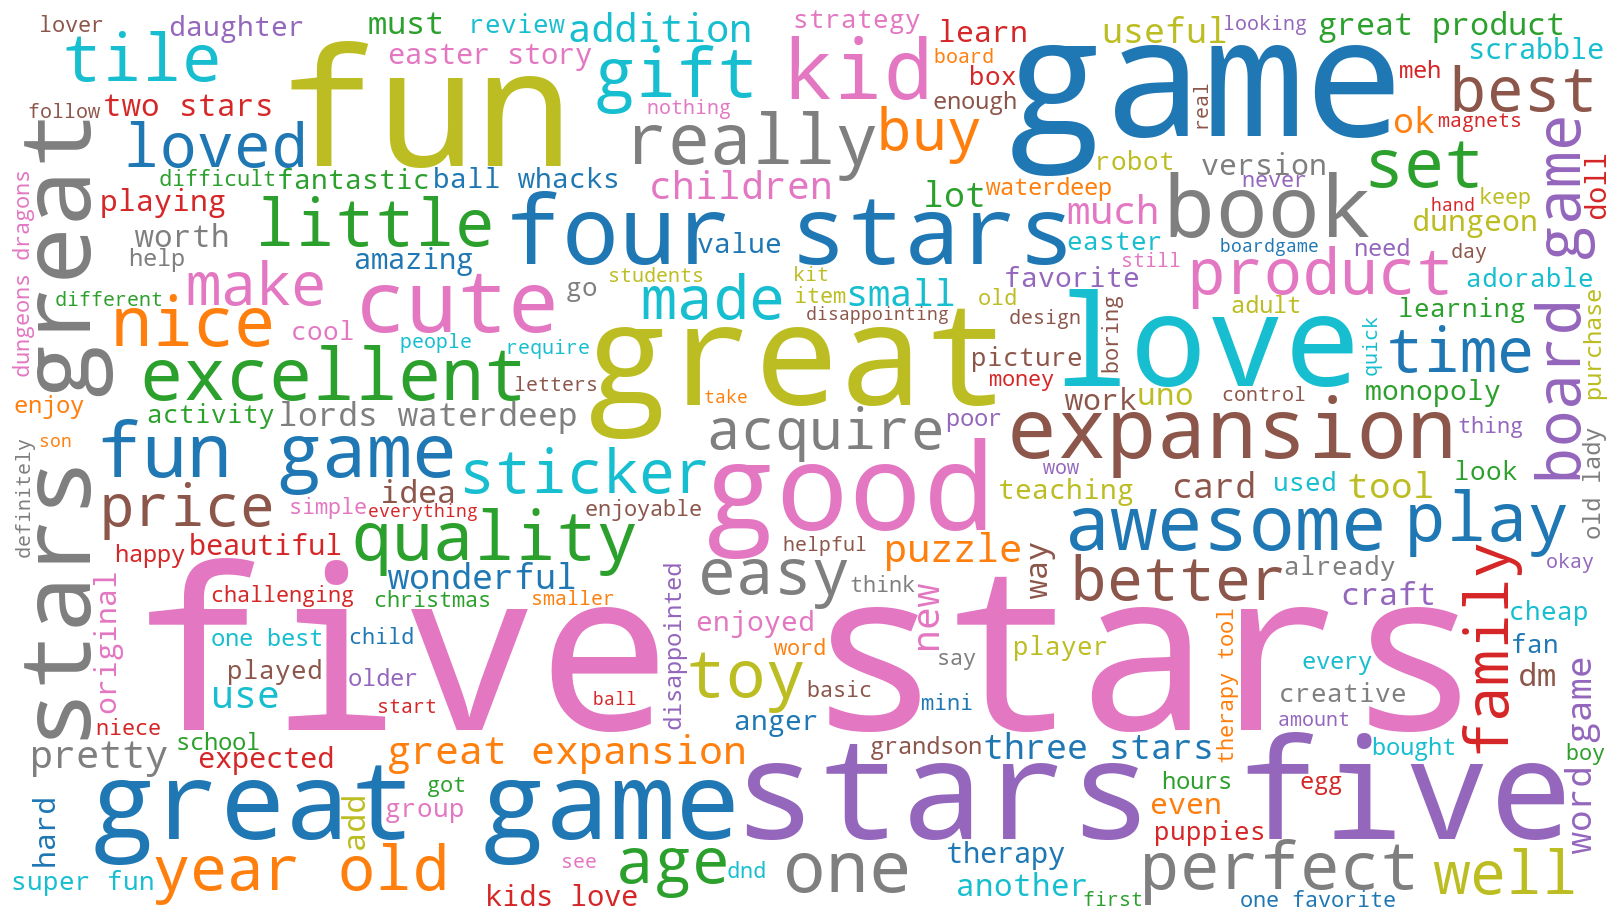

In [117]:
# Plot the WordCloud image from summary.                        
plt.figure(figsize = (16, 9), facecolor = None) 
plt.imshow(summary_wordcloud) 
plt.axis('off') 
plt.tight_layout(pad = 0) 

plt.savefig('cloud_summary.png')
plt.show()

### 4d) Identify 15 most common words and polarity

In [118]:
# Determine the 15 most common words.
# Generate a DataFrame from Counter.
review_counts = pd.DataFrame(Counter(review_no_sw).most_common(15),
                      columns=['Word', 'Frequency']).set_index('Word')

# Preview data.
review_counts

,Frequency
Word,
game,1713
great,598
fun,558
one,540
play,509
like,421
love,332
get,320
really,319


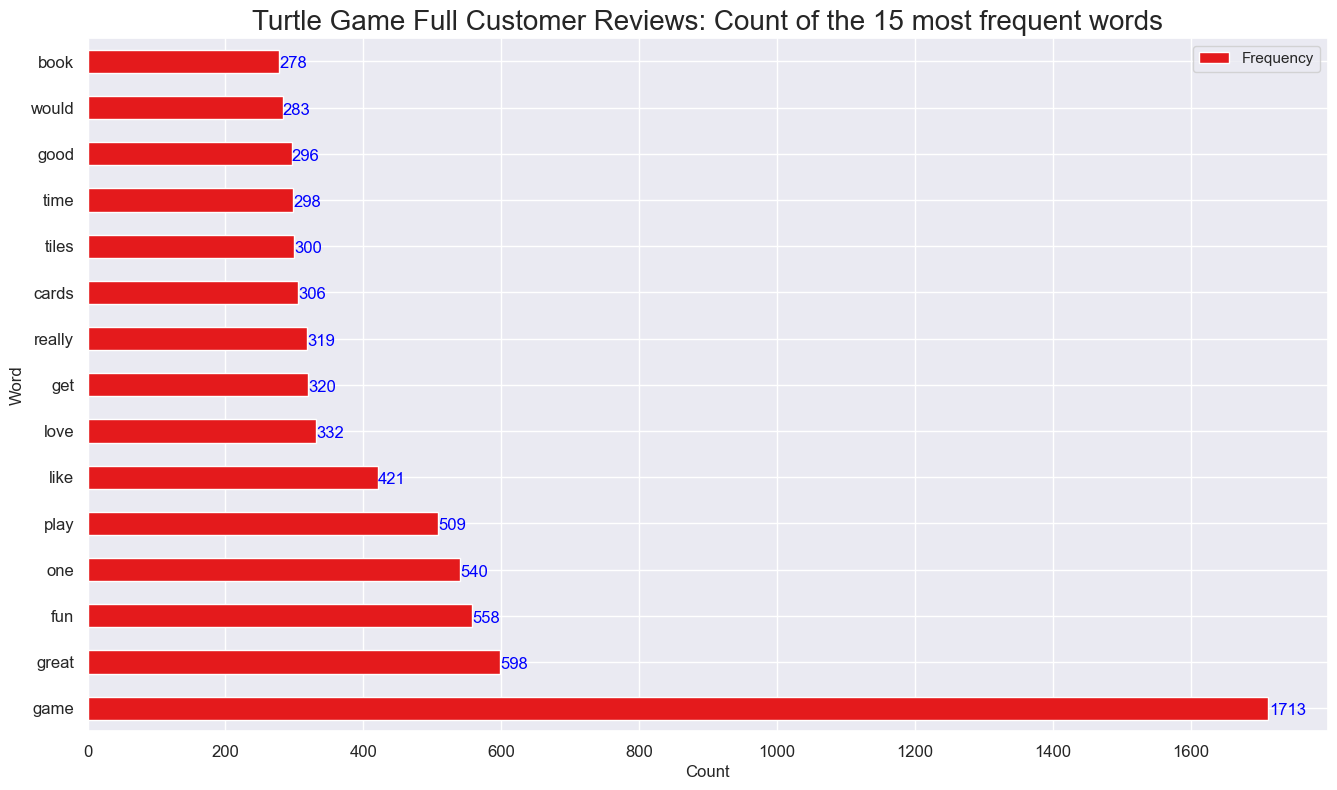

In [119]:
# Set the plot type.
ax = review_counts.plot(kind='barh', figsize=(16, 9), fontsize=12,
                 colormap ='Set1')

# Set the labels.
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Word', fontsize=12)
ax.set_title("Turtle Game Full Customer Reviews: Count of the 15 most frequent words",
             fontsize=20)

# Draw the bar labels.
for i in ax.patches:
    ax.text(i.get_width()+.41, i.get_y()+.1, str(round((i.get_width()), 2)),
            fontsize=12, color='blue')

In [120]:
# Determine the 15 most common words in summary tokens without stopwords.
# Generate a DataFrame from Counter.
summary_counts = pd.DataFrame(Counter(summary_no_sw).most_common(15),
                      columns=['Word', 'Frequency']).set_index('Word')

# Preview data.
summary_counts

,Frequency
Word,
stars,466
five,381
game,319
great,296
fun,218
love,93
good,93
four,58
like,54


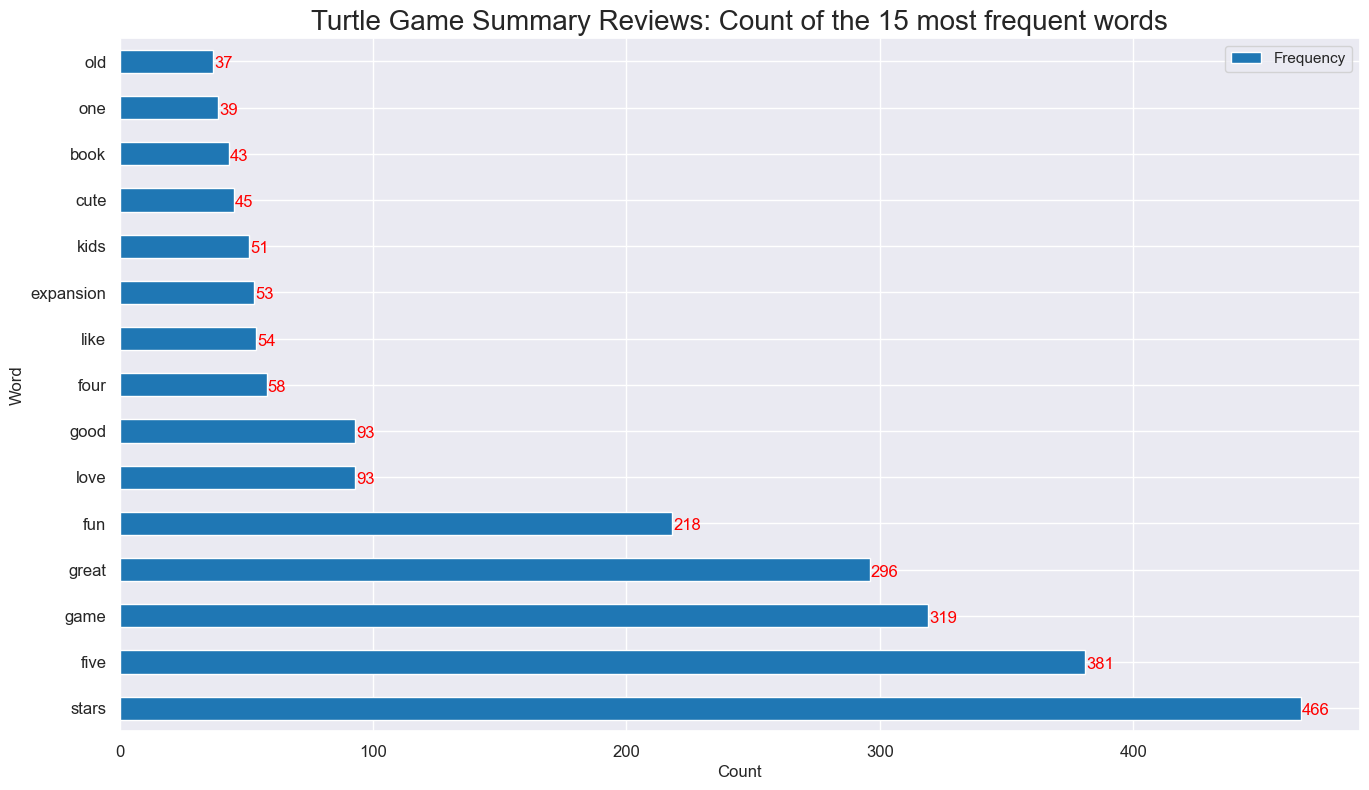

In [121]:
# Set the plot type.
ax = summary_counts.plot(kind='barh', figsize=(16, 9), fontsize=12,
                 colormap ='tab10')

# Set the labels.
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Word', fontsize=12)
ax.set_title("Turtle Game Summary Reviews: Count of the 15 most frequent words",
             fontsize=20)

# Draw the bar labels.
for i in ax.patches:
    ax.text(i.get_width()+.41, i.get_y()+.1, str(round((i.get_width()), 2)),
            fontsize=12, color='red')

- The most frequent words in both full and summary reviews are all positive - this suggests that customers feel very positive about Turtle Game's products.
- In summary reviews it should be noted that the words 'five' and 'stars' (the two most common words) will almost always occur together. 'Stars' is more frequent as it may also be paired with other words ('four' or 'three' etc).

## 5. Review polarity and sentiment: Plot histograms of polarity (use 15 bins) and sentiment scores for the respective columns.

- Note that the comment 'five stars' is scored with a polarity of 0, even though it should be a strongly positive comment.

In [122]:
# Provided function.
def generate_polarity(comment):
    '''Extract polarity score (-1 to +1) for each comment'''
    return TextBlob(comment).sentiment[0]

In [123]:
# Ddf3['review_polarity'] = df3['review'].apply(generate_polarity)
df5['review_polarity'] = df5['review'].apply(generate_polarity)
df5['summary_polarity'] = df5['summary'].apply(generate_polarity)

# View output.
df5.head(20)

,review,summary,review_tokens,summary_tokens,review_polarity,summary_polarity
0,when it comes to a dm s screen the space on th...,the fact that 50 of this space is wasted on ar...,"[when, it, comes, to, a, dm, s, screen, the, s...","[the, fact, that, 50, of, this, space, is, was...",-0.036111,0.15000
1,an open letter to galeforce9 your unpainted mi...,another worthless dungeon master s screen from...,"[an, open, letter, to, galeforce9, your, unpai...","[another, worthless, dungeon, master, s, scree...",0.032684,-0.80000
2,nice art nice printing why two panels are fill...,pretty but also pretty useless,"[nice, art, nice, printing, why, two, panels, ...","[pretty, but, also, pretty, useless]",0.115410,0.00000
3,amazing buy bought it as a gift for our new dm...,five stars,"[amazing, buy, bought, it, as, a, gift, for, o...","[five, stars]",0.578788,0.00000
4,as my review of gf9 s previous screens these w...,money trap,"[as, my, review, of, gf9, s, previous, screens...","[money, trap]",-0.316667,0.00000
5,grandson loves,five stars,"[grandson, loves]","[five, stars]",0.000000,0.00000
6,i have bought many gm screens over the years b...,best gm screen ever,"[i, have, bought, many, gm, screens, over, the...","[best, gm, screen, ever]",0.660000,1.00000
7,came in perfect condition,five stars,"[came, in, perfect, condition]","[five, stars]",1.000000,0.00000
8,could be better but its still great i love the...,great but could be even better,"[could, be, better, but, its, still, great, i,...","[great, but, could, be, even, better]",0.372222,0.65000
9,my review will mirror others in that this kind...,another missed opportunity not a value add to ...,"[my, review, will, mirror, others, in, that, t...","[another, missed, opportunity, not, a, value, ...",0.150760,0.00000


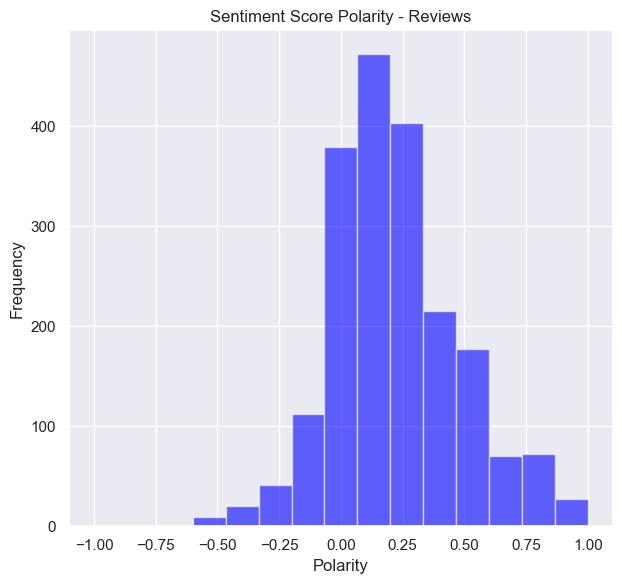

In [124]:
# Review: Create a histogram plot with bins = 15.

plt.figure(figsize=(12,6))

# Histogram of polarity
plt.subplot(1, 2, 1)
plt.hist(df5['review_polarity'], bins=15, color='blue', alpha = 0.6)
plt.title("Sentiment Score Polarity - Reviews")
plt.xlabel("Polarity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig('Histogram Sentiment Polarity Reviews.png')
plt.show()


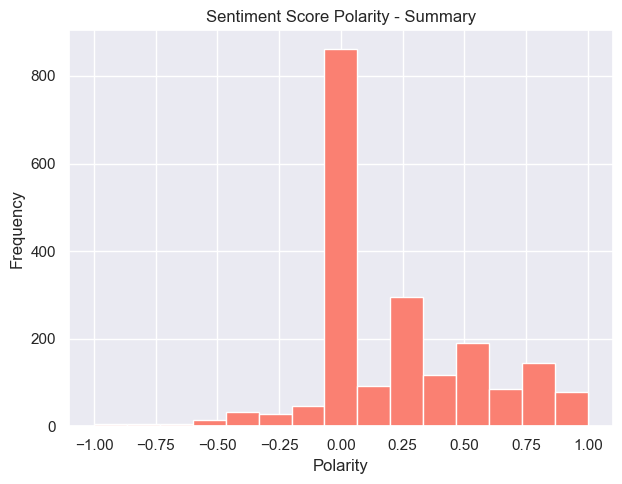

In [125]:
# Summary: Create a histogram plot with bins = 15.

plt.figure(figsize=(12,5))

# Histogram of polarity
plt.subplot(1, 2, 2)
plt.hist(df5['summary_polarity'], bins=15, color='salmon')
plt.title("Sentiment Score Polarity - Summary")
plt.xlabel("Polarity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig('Histogram Sentiment Polarity Summary.png')
plt.show()


## Subjectivity scores using TextBlob

In [126]:
# Define a function to extract a polarity score for the comment.
def generate_subjectivity(comment):
    return TextBlob(comment).sentiment[1]

# Determine polarity of both columns. 
df5['review_subjectivity'] = df5['review'].apply(generate_subjectivity)
df5['summary_subjectivity'] = df5['summary'].apply(generate_subjectivity)

# View output.
df5.head(20)

,review,summary,review_tokens,summary_tokens,review_polarity,summary_polarity,review_subjectivity,summary_subjectivity
0,when it comes to a dm s screen the space on th...,the fact that 50 of this space is wasted on ar...,"[when, it, comes, to, a, dm, s, screen, the, s...","[the, fact, that, 50, of, this, space, is, was...",-0.036111,0.15000,0.486111,0.500000
1,an open letter to galeforce9 your unpainted mi...,another worthless dungeon master s screen from...,"[an, open, letter, to, galeforce9, your, unpai...","[another, worthless, dungeon, master, s, scree...",0.032684,-0.80000,0.440206,0.900000
2,nice art nice printing why two panels are fill...,pretty but also pretty useless,"[nice, art, nice, printing, why, two, panels, ...","[pretty, but, also, pretty, useless]",0.115410,0.00000,0.427755,0.733333
3,amazing buy bought it as a gift for our new dm...,five stars,"[amazing, buy, bought, it, as, a, gift, for, o...","[five, stars]",0.578788,0.00000,0.784848,0.000000
4,as my review of gf9 s previous screens these w...,money trap,"[as, my, review, of, gf9, s, previous, screens...","[money, trap]",-0.316667,0.00000,0.316667,0.000000
5,grandson loves,five stars,"[grandson, loves]","[five, stars]",0.000000,0.00000,0.000000,0.000000
6,i have bought many gm screens over the years b...,best gm screen ever,"[i, have, bought, many, gm, screens, over, the...","[best, gm, screen, ever]",0.660000,1.00000,0.700000,0.300000
7,came in perfect condition,five stars,"[came, in, perfect, condition]","[five, stars]",1.000000,0.00000,1.000000,0.000000
8,could be better but its still great i love the...,great but could be even better,"[could, be, better, but, its, still, great, i,...","[great, but, could, be, even, better]",0.372222,0.65000,0.463889,0.625000
9,my review will mirror others in that this kind...,another missed opportunity not a value add to ...,"[my, review, will, mirror, others, in, that, t...","[another, missed, opportunity, not, a, value, ...",0.150760,0.00000,0.505054,0.000000


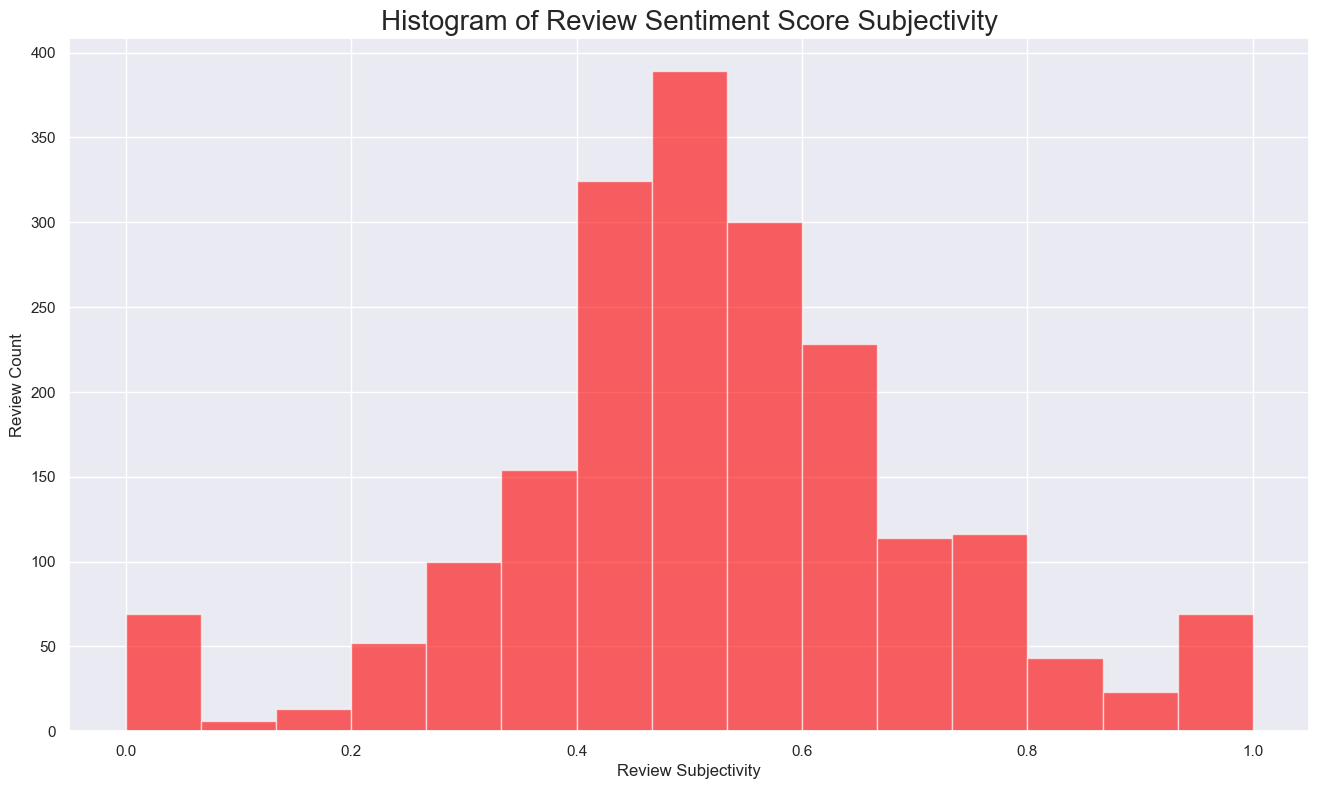

In [127]:
# Review: Create a histogram plot with bins = 15.
# Histogram of subjectivity score for reviews
# Set the number of bins.
num_bins = 15

# Set the plot area.
plt.figure(figsize=(16,9))

# Define the bars.
n, bins, patches = plt.hist(df5['review_subjectivity'], num_bins, facecolor='red', alpha=0.6)

# Set the labels.
plt.xlabel('Review Subjectivity', fontsize=12)
plt.ylabel('Review Count', fontsize=12)
plt.title('Histogram of Review Sentiment Score Subjectivity', fontsize=20)

plt.show()

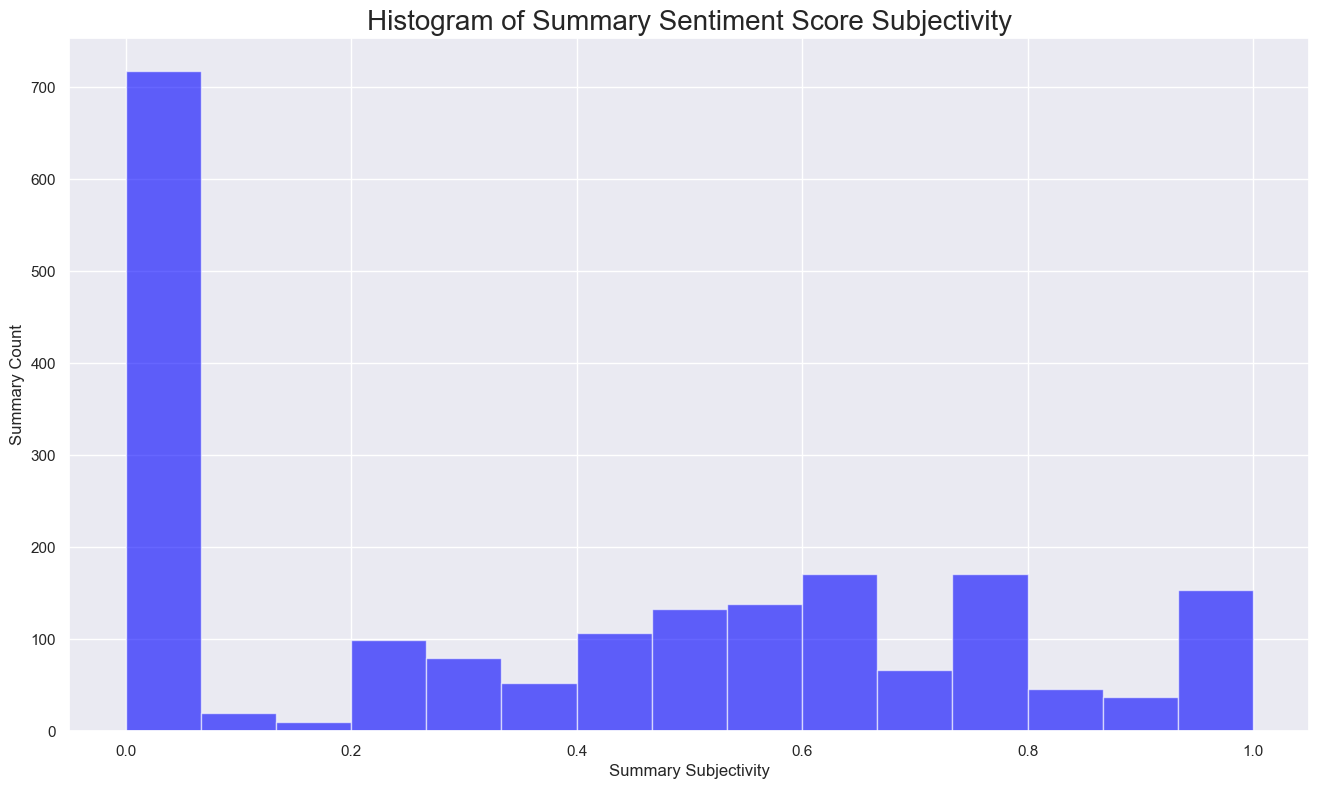

In [128]:
# Review: Create a histogram plot with bins = 15.
# Histogram of polarity subjectivity score for summary
# Set the number of bins.
num_bins = 15

# Set the plot area.
plt.figure(figsize=(16,9))

# Define the bars.
n, bins, patches = plt.hist(df5['summary_subjectivity'], num_bins, facecolor='blue', alpha=0.6)

# Set the labels.
plt.xlabel('Summary Subjectivity', fontsize=12)
plt.ylabel('Summary Count', fontsize=12)
plt.title('Histogram of Summary Sentiment Score Subjectivity', fontsize=20)

plt.show()

- The text blob polarity analysis shows that most reviews and summaries are positive. 
- The polarity analysis for summary and reviews does not properly score the statement 'five stars' - it is rated as neutral when it should be positive, therefore neutral reviews are over-represented.

## 6. Identify top 20 positive and negative reviews and summaries respectively

In [129]:
# Make a copy of df5
df6 = df5.copy()

# View DataFrame
df6.head()

,review,summary,review_tokens,summary_tokens,review_polarity,summary_polarity,review_subjectivity,summary_subjectivity
0,when it comes to a dm s screen the space on th...,the fact that 50 of this space is wasted on ar...,"[when, it, comes, to, a, dm, s, screen, the, s...","[the, fact, that, 50, of, this, space, is, was...",-0.036111,0.15,0.486111,0.500000
1,an open letter to galeforce9 your unpainted mi...,another worthless dungeon master s screen from...,"[an, open, letter, to, galeforce9, your, unpai...","[another, worthless, dungeon, master, s, scree...",0.032684,-0.80,0.440206,0.900000
2,nice art nice printing why two panels are fill...,pretty but also pretty useless,"[nice, art, nice, printing, why, two, panels, ...","[pretty, but, also, pretty, useless]",0.115410,0.00,0.427755,0.733333
3,amazing buy bought it as a gift for our new dm...,five stars,"[amazing, buy, bought, it, as, a, gift, for, o...","[five, stars]",0.578788,0.00,0.784848,0.000000
4,as my review of gf9 s previous screens these w...,money trap,"[as, my, review, of, gf9, s, previous, screens...","[money, trap]",-0.316667,0.00,0.316667,0.000000


## Distribution of the Comments by Sentiment Category

In [130]:
# Apply sentiment classification to both columns
def categorize(x):
    if x > 0.05:
        return 'positive'
    elif x < -0.05:
        return 'negative'
    else:
        return 'neutral'

df6['review_sentiment'] = df6['review_polarity'].apply(categorize)
df6['summary_sentiment'] = df6['summary_polarity'].apply(categorize)


# Reshape df6 into long format
df6_melted = df6.melt(
    value_vars=['review_sentiment', 'summary_sentiment'],
    var_name='Type',
    value_name='Sentiment'
)


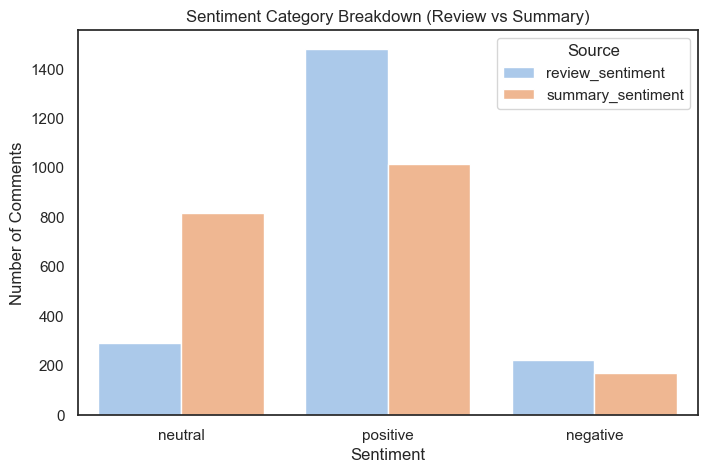

In [131]:
# Define custom palette
sentiment_palette = {
    'positive': 'seagreen',
    'neutral': 'gray',
    'negative': 'firebrick'
}

sns.set_theme(style="white")

# Create a barplot to show the Sentiment Category Breakdown
plt.figure(figsize=(8, 5))
sns.countplot(data=df6_melted, x='Sentiment', hue='Type', palette='pastel')

plt.title('Sentiment Category Breakdown (Review vs Summary)')
plt.xlabel('Sentiment')
plt.ylabel('Number of Comments')
plt.legend(title='Source')
plt.savefig('Sentiment Category Breakdown.png')
plt.show()

In [132]:
# Create a subset of reviews with 'review' and 'summary' as df4.
df7 = reviews[['review', 'summary']]

# View DataFrame.
df7.head(10)

,review,summary
0,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,As my review of GF9's previous screens these w...,Money trap
5,Grandson loves,Five Stars
6,"I have bought many gm screens over the years, ...",Best gm screen ever
7,Came in perfect condition.,Five Stars
8,Could be better but its still great. I love th...,Great but could be even better
9,My review will mirror others in that this kind...,Another missed opportunity. Not a value add t...


In [133]:
# Import the vader lexicon and vader class.
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Create a variable to store the sia.
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/rakshanama/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [134]:
# Calculate compound, positive, neutral and negative scores for review.
df7['review_compound'] = [sia.polarity_scores(x)['compound'] for x in df7['review']]
df7['review_neg'] = [sia.polarity_scores(x)['neg'] for x in df7['review']]
df7['review_neutral'] = [sia.polarity_scores(x)['neu'] for x in df7['review']]
df7['review_pos'] = [sia.polarity_scores(x)['pos'] for x in df7['review']]

In [135]:
df7[['review','review_compound','review_neg','review_neutral','review_pos']].head()

,review,review_compound,review_neg,review_neutral,review_pos
0,"When it comes to a DM's screen, the space on t...",-0.7406,0.109,0.856,0.035
1,An Open Letter to GaleForce9*:\n\nYour unpaint...,0.9433,0.092,0.703,0.205
2,"Nice art, nice printing. Why two panels are f...",0.6939,0.122,0.723,0.155
3,Amazing buy! Bought it as a gift for our new d...,0.8997,0.000,0.477,0.523
4,As my review of GF9's previous screens these w...,-0.6808,0.203,0.797,0.000


In [136]:
# Top 20 negative reviews.
negative_reviews = df7.nsmallest(20, 'review_compound')


# Eliminate unnecessary columns.
negative_reviews = negative_reviews[['review', 'review_compound', 'review_neg']]

# Adjust the column width.
negative_reviews.style.set_properties(subset=['review'], **{'width': '1200px'})

# View Output.

In [137]:
# View Top 20 negative reviews only.
pd.set_option('display.max_colwidth', None)
negative_reviews[['review']].head(20)

review
1119  Here is my review, cross-posted from boardgamegeek.com:\n\nI have fond memories of D&D from my youth, that I occasionally attempt to recapture. I remember the sense of vague foreboding conjured by RPG-like board games such as Runequest and Spacehulk. I had read some favorable reviews of the new "RPG-as-boardgame" series promoted by Wizards on the Coast, and I was excited to try this. I splunked down my hard-earned cash and amazon duly delivered a hefty box of dreams to my doorstep.\n\nWrath of Ashardalon and I had some good times initially. My friends and I gamely punched all the cardboard pieces out of the sprues. We love punching pieces out of sprues! It inspires a sense of childlike wonder and anticipation in us! This tile has a Horrid Chamber on it! That dungeon tile has dead bodies! Ooh, I wonder what a flaming sphere does? These cards all have various powers and spells on them! Look, you can play a dragon character! And the plastic figurines were enjoyable, similar to those plastic dinosaurs we all had as kids. Whee!\n\nSadly, that was the best part of the game. Everything went downhill when we actually started to play.\n\nThe game itself is a reductionist vision of a dungeon crawl. It is, unfortunately, so reductionist that is effectively a game of Munchkin, but without a sense of humor. I think the game designers must have sensed this, and to try to add a sense of danger and urgency to the game, they created a deck of sadistic Encounter cards to punish us for playing. (But more about those later.)\n\nThe players progress through the dungeon together. At every unexplored edge, they "kick down the door" and grow the dungeon by one (1) new dungeon tile, guaranteed to contain exactly one (1) new monster, and possible an Encounter card (which is invariably unpleasant). This game might have been interesting if every new corner of the dungeon had produced a novel challenge for the players to make strategic decisions about together. Instead, the players typically have one power which is the min-max best option for any given monster, and they use it, over and over again. The twenty-sided die is rolled. The monster advances. It does a hit point of damage to the wizard! And then it dies. And drops a treasure.\n\nIt's difficult to be heroic in this game. The characters are punished for pushing forward into the darkness. They are also punished for standing still. They are punished for gathering together on one tile, and they are punished for spreading out. There are precious few strategic decisions to be made in this game.\n\nAll of this is incredibly tedious and dull. I magic missile the darkness.\n\nThe power cards feel poorly thought out, poorly worded, and disappointing. The "Hypnosis" card, seems promising: it can cause one monster to attack another! My goodness, a card that allows the players to turn the dungeon against itself! Strategy! But no. Unlike the Scroll of Monster Control item, which replaces a monster's attack on the players, Hypnosis simply supplements the monster's action with it's "hypnotized" attack. But can the power at least let the players turn the Cave Bear's awesome Claws attack against the Kobold horde? No, not really. The monster's attack is reduced to a standardized "Attack +9, Damage 1," as printed on the card. Really, this card is a +9, 1 damage attack that only works if two monsters are in the same room. Is this what the game designers intended? Who knows! But hey, that's what it says on the card.\n\nIf the player's powers are boring, at least the game designers also gave us Encounter cards. We scrubbed through the rules multiple times, certain we were misinterpreting them. But no: every player will typically draw at least one encounter card every turn. Thus, a four-player band of characters fighting a monster will typically draw four encounter cards every round of combat. Sadly, the encounter cards aren't terribly creative. They all seem to be variants of "Random thing happens! And ever

In [138]:
# Top 20 positive reviews.
positive_reviews = df7.nlargest(20, 'review_compound')

# Eliminate unnecessary columns.
positive_reviews = positive_reviews[['review', 'review_compound']]

# Adjust the column width.
positive_reviews.style.set_properties(subset=['review'], **{'width': '1200px'})

# View output.

In [139]:
# View Top 20 positive reviews only.
pd.set_option('display.max_colwidth', None)
positive_reviews[['review']].head(20)

review
1121                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      Disclaimer: Bought this from a local store. Paid list value, but supporting local game stores helps keep them in business, and it's a rough market to keep a gaming store running. Also, I do not own, nor have I played&nbsp;<a data-hook="product-link-linked" class="a-link-normal" href="/Dungeons-Dragons-Castle-Ravenloft-Board-Game/dp/0786955570/ref=cm_cr_arp_d_rvw_txt?ie=UTF8">Dungeons & Dragons: Castle Ravenloft Board Game</a>, the first D&D Adventures Board Game. Regardless...\n\nDungeons & Dragons: Wrath of Ashardalon Board Game (WoA) is a fantastic value at $65 (list). You get 42 (plastic, unpainted) minis (1" scale), you get a nice set of cardboard interlocking(!) dungeon tiles, and you get a fun, very random, board game playable either by yourself or with up to 4 friends.\n\nWhat it is:\nWoA is, in gamer terms, a roguelike in tabletop form. In layman's terms, WoA is a dungeon crawler. You start at the entrance, and have a specific goal (rescue the villagers, survive the dungeon, destroy the altar, slay the dragon). The adventures are built randomly based on shuffling the tiles, and they are played individually as you explore. You can go for a massive linear dungeon based on a little luck and careful planning, or you can attempt to condense yourself in a larger swarm interconnected tunnels.\n\nSome of the adventures feature "chambers", special larger rooms that are all placed at once and filled with enemies and a specific goal that the team must complete to win the adventure.\n\nIt's a great way to introduce someone into tabletop roleplaying gaming, it's the perfect medium between a board game and an actual pen and paper RPG.\n\nIt's a fun, quick* game to run a quick adventure for some friends taking anywhere between 20 minutes and an hour per adventure.\n\nWhat it isn't:\nA deeper rolepla

In [140]:
# Calculate compound, positive, neutral and negative scores for summary.
df7['summary_compound'] = [sia.polarity_scores(x)['compound'] for x in df7['summary']]
df7['summary_neg'] = [sia.polarity_scores(x)['neg'] for x in df7['summary']]
df7['summary_neutral'] = [sia.polarity_scores(x)['neu'] for x in df7['summary']]
df7['summary_pos'] = [sia.polarity_scores(x)['pos'] for x in df7['summary']]

In [141]:
df7[['summary','summary_compound','summary_neg','summary_neutral','summary_pos']].head()

,summary,summary_compound,summary_neg,summary_neutral,summary_pos
0,The fact that 50% of this space is wasted on art (and not terribly informative or needed art ...,-0.0711,0.138,0.735,0.126
1,Another worthless Dungeon Master's screen from GaleForce9,-0.4404,0.326,0.674,0.000
2,"pretty, but also pretty useless",0.4019,0.306,0.165,0.529
3,Five Stars,0.0000,0.000,1.000,0.000
4,Money trap,-0.3182,0.697,0.303,0.000


In [142]:
# Top 20 negative summaries.
negative_summaries = df7.nsmallest(20, 'summary_compound')

# Eliminate unnecessary columns.
negative_summaries = negative_summaries[['summary','summary_compound','review_compound']]

# Adjust the column width.
negative_summaries.style.set_properties(subset=['summary'], **{'width': '1200px'})

# View output.

,summary,summary_compound,review_compound
882,"A crappy cardboard ghost of the original. Hard to believe they did this, but they did. Shame on Hasbro. Disgusting.",-0.905200,-0.905200
1565,"The TARDIS, The Doctor, River Song, Amy, Rory Fight Every Enemy - In Cards!",-0.750000,0.966100
947,No 20 sided die,-0.726900,0.000000
328,Defective- poor QC,-0.718400,0.976500
1003,Then you will find this board game to be dumb and boring,-0.680800,-0.493900
1166,before this I hated running any RPG campaign dealing with towns because it ...,-0.636900,-0.726900
426,but it gets repetitive and the students start to get bored after about half a round,-0.631000,-0.812600
847,Worst quality adult board game I've even seen,-0.624900,0.058300
173,Horrible! Nothing more to say Would give zero stars ...,-0.584800,-0.584800
364,Anger Control game,-0.571900,-0.413100


In [143]:
# View Top 20 negative summaries only.
pd.set_option('display.max_colwidth', None)
negative_summaries[['summary']].head(20)

,summary
882,"A crappy cardboard ghost of the original. Hard to believe they did this, but they did. Shame on Hasbro. Disgusting."
1565,"The TARDIS, The Doctor, River Song, Amy, Rory Fight Every Enemy - In Cards!"
947,No 20 sided die
328,Defective- poor QC
1003,Then you will find this board game to be dumb and boring
1166,before this I hated running any RPG campaign dealing with towns because it ...
426,but it gets repetitive and the students start to get bored after about half a round
847,Worst quality adult board game I've even seen
173,Horrible! Nothing more to say Would give zero stars ...
364,Anger Control game


- The negative reviews are the most useful to Turtle Games - a look at the words used here could indicate areas for product improvement.
- 'Quality' (in a negative context) is mentioned frequently in the most negative reviews, so Turtle Games should review their product quality assurance processes.

In [144]:
# Top 20 positive summaries.
positive_summaries = df7.nlargest(20, 'summary_compound')

# Eliminate unnecessary columns.
positive_summaries = positive_summaries[['summary','summary_compound','review_compound']]

# Adjust the column width.
positive_summaries.style.set_properties(subset=['summary'], **{'width': '1200px'})

# View output.

,summary,summary_compound,review_compound
1201,Wow! What a great set of tiles for such a great price. A great starter set.,0.954500,0.959600
1699,"Great for playing, great for creative workshops too!",0.921500,0.970500
1121,Wrath of Ashardalon: great investment for an avid RPG fan who enjoys tabletop as well as CRPGs,0.918600,0.999500
1955,"Easy to learn, great fun to play!",0.918400,0.790600
703,"Great quality, very cute and perfect for my toddler",0.907300,0.912700
491,but the kids really like it and helps start good discussion,0.898800,0.898800
1845,"Fun, friendly, beautiful game!",0.893200,0.966500
1029,"Great game, great value.",0.891000,0.992800
1189,Great game. Value for the price is great also,0.891000,0.968900
973,I wish all those who buy better luck. Fairly easy to understand and plenty of ...,0.888500,0.800000


In [145]:
# View Top 20 positive summaries only.
pd.set_option('display.max_colwidth', None)
positive_summaries[['summary']].head(20)

,summary
1201,Wow! What a great set of tiles for such a great price. A great starter set.
1699,"Great for playing, great for creative workshops too!"
1121,Wrath of Ashardalon: great investment for an avid RPG fan who enjoys tabletop as well as CRPGs
1955,"Easy to learn, great fun to play!"
703,"Great quality, very cute and perfect for my toddler"
491,but the kids really like it and helps start good discussion
1845,"Fun, friendly, beautiful game!"
1029,"Great game, great value."
1189,Great game. Value for the price is great also
973,I wish all those who buy better luck. Fairly easy to understand and plenty of ...


## Relationship between review and summary compound scores

In [146]:
# Creating a separate DataFrame to include polarity and compound of both reviews and summaries.
df8 = df7.copy()

df8['review_polarity'] = df8['review'].apply(generate_polarity)
df8['summary_polarity'] = df8['summary'].apply(generate_polarity)


df8.head()

,review,summary,review_compound,review_neg,review_neutral,review_pos,summary_compound,summary_neg,summary_neutral,summary_pos,review_polarity,summary_polarity
0,"When it comes to a DM's screen, the space on the screen itself is at an absolute premium. The fact that 50% of this space is wasted on art (and not terribly informative or needed art as well) makes it completely useless. The only reason that I gave it 2 stars and not 1 was that, technically speaking, it can at least still stand up to block your notes and dice rolls. Other than that, it drops the ball completely.",The fact that 50% of this space is wasted on art (and not terribly informative or needed art ...,-0.7406,0.109,0.856,0.035,-0.0711,0.138,0.735,0.126,-0.036111,0.15
1,"An Open Letter to GaleForce9*:\n\nYour unpainted miniatures are very not bad. Your spell cards are great. Your board games are ""meh"". Your DM screens, however, are freaking terrible. I'm still waiting for a single screen that isn't polluted with pointless artwork where useful, reference-able tables should be. Once again, you've created a single use screen that is only useful when running the ""Storm King's Thunder"" adventure. Even despite the fact that it's geared to that adventure path, it's usefulness negligible, at best. I massive swath of the inner panel is wasted on artwork and a bloated overland map, which could have been easily reduced to a single panel in size. And the few table you have are nigh-useless themselves.\n\nIn short, stop making crap DM screens.",Another worthless Dungeon Master's screen from GaleForce9,0.9433,0.092,0.703,0.205,-0.4404,0.326,0.674,0.000,0.035952,-0.80
2,"Nice art, nice printing. Why two panels are filled with a general Forgotten Realms map is beyond me. Most of one of them is all blue ocean. Such a waste.\n\nI don't understand why they can't make these DM Screens more useful for these ""kinds of adventures"" rather than solely the specific adventure. You're supposed to be able to transpose this adventure to other lands outside the Forgotten Realms. So even just a list of new monsters or NPCs would at least be useful than the map. Even more would just be stuff related to running the game but broad-use stuff related to giants.\n\nSame thing with Curse of Strahd. Why not make it useful for raven loft, undead or horror campaigns in general... instead a huge amount of screen space is solely mapping out Castle Ravenloft, which is only useful during a small fraction of the time even for the Curse of Strahd adventure, let alone various other Ravenloft adventuring.\n\nThey really kill the extended use of these screens by not thinking about their potential use, both for the adventure in question, as well as use in a broader sense.\n\nThe Rage of Demons screen is far more useful for broad under dark adventuring - covering a lot of rules for the various conditions you may suffer... and the map is only one panel.\n\nThis Storm Giants one is decent for a few tables it includes - but really misses the mark. Maybe they should ask a few DMs what they would use?","pretty, but also pretty useless",0.6939,0.122,0.723,0.155,0.4019,0.306,0.165,0.529,0.116640,0.00
3,Amazing buy! Bought it as a gift for our new dm and it's perfect!,Five Stars,0.8997,0.000,0.477,0.523,0.0000,0.000,1.000,0.000,0.628788,0.00
4,"As my review of GF9's previous screens these were completely unnecessary and nearly useless. Skip them, this is the definition of a waste of money.",Money trap,-0.6808,0.203,0.797,0.000,-0.3182,0.697,0.303,0.000,-0.316667,0.00


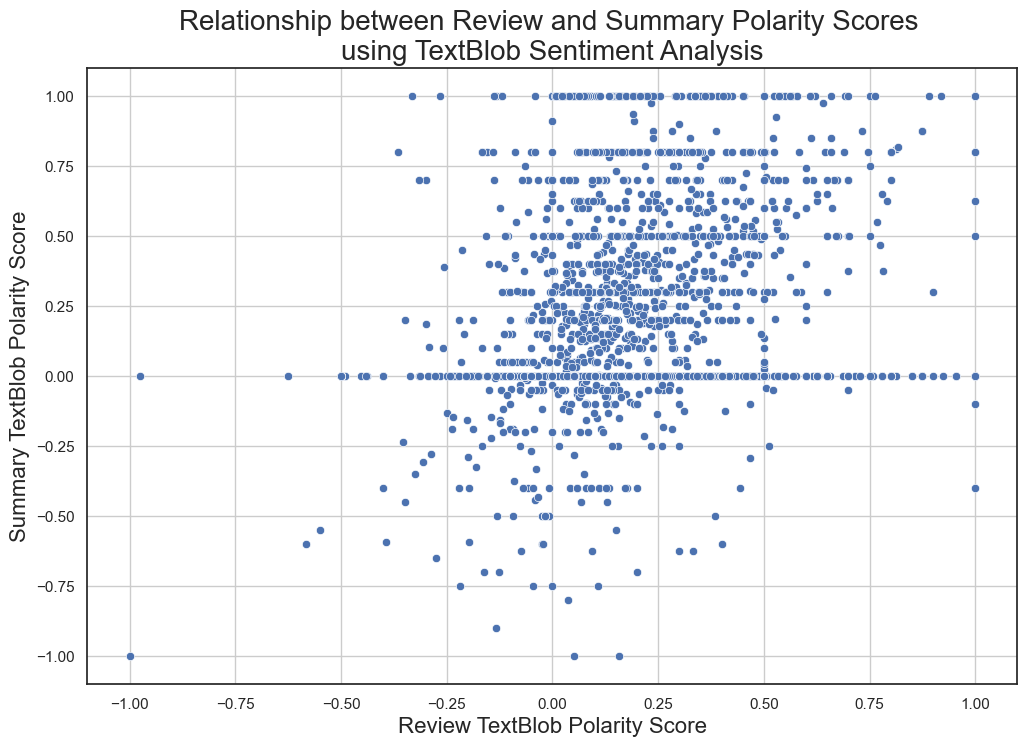

In [147]:
# Plot review and summary Vader compound scores.
plt.figure(figsize=(12,8))
sns.scatterplot(data=df8, x='review_polarity', y='summary_polarity')

# Set the labels.

plt.xlabel('Review TextBlob Polarity Score', fontsize=16)
plt.ylabel('Summary TextBlob Polarity Score', fontsize=16)
plt.title("Relationship between Review and Summary Polarity Scores \nusing TextBlob Sentiment Analysis", fontsize=20);
plt.grid()
plt.savefig('textblob.png')

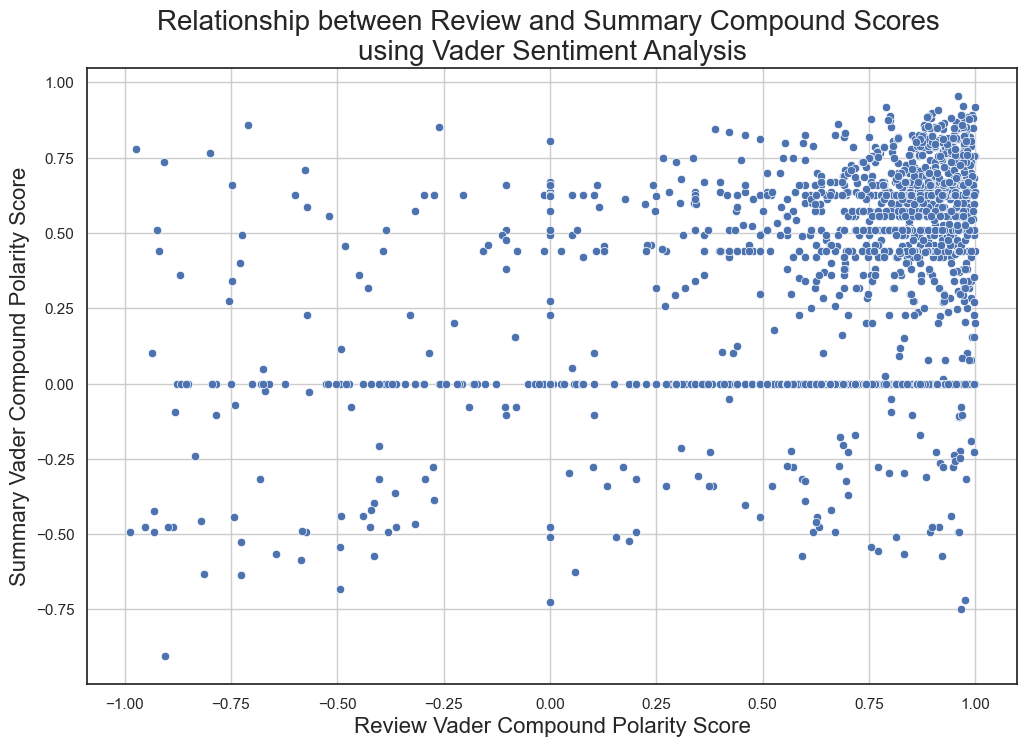

In [148]:
# Plot review and summary Vader compound scores.
plt.figure(figsize=(12,8))
sns.scatterplot(data=df8, x='review_compound', y='summary_compound')

# Set the labels.
plt.xlabel('Review Vader Compound Polarity Score', fontsize=16)
plt.ylabel('Summary Vader Compound Polarity Score', fontsize=16)
plt.title("Relationship between Review and Summary Compound Scores \nusing Vader Sentiment Analysis", fontsize=20);
plt.grid()
plt.savefig('vader.png')

- These scatter plots show a weak positive correlation between review and summary polarity with a TextBlob analysis.
- The Vader analysis general scores a larger number of reviews and summaries as positive but there is less evidence of a positive association between review and summary polarity.
- Both plots show a high number of summaries scored with a polarity of 0, many of which are in fact positive.

## 7. Discuss: Insights and observations

-	The most frequent words in both summary and reviews are all positive suggesting that customers feel very positive about Turtle Games’ products.
-	The TextBlob polarity analysis of both reviews and summaries are positive; however, polarity analysis for summaries and reviews does not properly score ‘five stars’ – it is rated as neutral when it should be positive, which leads to the overrepresentation of neutral reviews.
-	The overall sentiment by category was positive.
-	Negative reviews are the most useful to Turtle Game – a look at the words used could indicate areas for product improvement.
-	The word ‘Quality’ (appears in a negative context) is mentioned frequently in more negative reviews/summaries, implying that Turtle Games should review their product quality assurance processes. 
- The relationship between the two variables: Review and Summary is more evident in the TextBlob analysis.
- Factors to explore further would be to see if particular games were associated with positive or negative reviews.


# 